# Teach RNN Motion

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [373]:
# System imports
from pathlib import Path
import sys
from datetime import date
from collections import defaultdict
import json

# Plotting imports
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Scientific imports
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import zscore, spearmanr
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

# NN imports
import torch
import neurogym as ngym

# For import from src folder in linux
ROOT = Path().cwd().parent
SRC_PATH = ROOT / 'src'
sys.path.append(str(ROOT))
sys.path.append(str(SRC_PATH))

# Custom imports
from src.environments import TAMTask, MotionTask, load_motion_from_image, load_tam_from_image
from src.train_test_utils import plot_dataset, plot_training_curves
from src.networks import TAMNet
from src.utils import load_params

In [838]:
# Plotting settings
custom_palette = sns.color_palette(["#E74C3C", "#2ECC71"]) # a custom palette with red and green
custom_params = {
    "axes.spines.right": False,
    "axes.spines.top": False
}
sns.set_theme(
    font_scale=1,
    style='white',
    context='poster',
    font='Franklin Gothic Book',
    rc=custom_params
)

## 0. Basic settings


In [137]:
%matplotlib inline

In [138]:
# Set directories
# Figures
today = date.today().strftime('%m-%d-%Y')
FIG_DIR = ROOT / 'figures' / today
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Network
MODEL_DIR = ROOT / 'data' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Stimuli
STIM_DIR = ROOT / 'data' / 'stimuli' / "TAM_basic"

In [217]:
# Load parameters
params = load_params(str(ROOT / 'parameters.json'))
exp_params = params["EXPERIMENT"]
env_params = params['TASK']
training_envs = defaultdict()
training_datasets = defaultdict()
motion_dirs = ["horizontal"]
box_shapes = ["square", "circle", "triangle"]

img_size = 32
batch_size = 128
seq_len = 10

In [218]:
# WORKED
# img_size = 64
# batch_size = 16
# seq_len = 100

# Higher batch size generalizes to other shapes
# Higher seq_len generalizes to outlines

In [219]:
# Create environments and datasets
for md in motion_dirs:
    for bs in box_shapes:
        print(md, bs)
        stimuli = load_tam_from_image(img_size, stim_path=STIM_DIR)
        env = TAMTask(
            box_shape=bs,
            stim_type="tam",
            stimuli=stimuli,
            stim_ori=md,
            dt=env_params["dt"],
            # sigma=env_params["sigma"],
            sigma=0,
            img_size=img_size
        )
        env.reset(no_step=True)

        # Generate dataset object
        dataset = ngym.Dataset(
            env,
            batch_size=batch_size,
            seq_len=seq_len
        )

        # Add dataset to dictionary
        training_envs[f'{bs}-{md}'] = env
        training_datasets[f'{bs}-{md}'] = dataset

horizontal square
horizontal circle
horizontal triangle


In [220]:
# Create environments and datasets
tam_test_datasets = defaultdict()
motion_test_datasets = defaultdict()
tam_types = ["tam", "outline"]
motion_types = ["cnt", "track"]

for bs in box_shapes:
    for tt in tam_types:
        for md in motion_dirs:
            print(bs, tt, md)
            if tt == "tam":
                _path = STIM_DIR
            else:
                _path = STIM_DIR.parent / "TAM_outline"

            stimuli = load_tam_from_image(img_size, stim_type=tt, stim_path=_path)
            env = TAMTask(
                box_shape=bs,
                stimuli=stimuli,
                stim_type=tt,
                stim_ori=md,
                dt=env_params["dt"],
                sigma=0.01,
                img_size=img_size
            )
            env.reset(no_step=True)

            # Generate dataset object
            dataset = ngym.Dataset(
                env,
                batch_size=batch_size,
                seq_len=seq_len
            )

            # Add dataset to dictionary
            tam_test_datasets[f'{bs}-{tt}-{md}'] = env
            tam_test_datasets[f'{bs}-{tt}-{md}'] = dataset

# for bs in box_shapes:
#     for mt in motion_types:
#         for md in motion_dirs:
#
#             print(bs, mt, md)
#
#             stimuli = load_motion_from_image(img_size, stim_path=STIM_DIR.parent / "motion_task")
#             env = MotionTask(
#                 dt=env_params["dt"],
#                 box_shape=bs,
#                 motion_type=mt,
#                 stim_ori=md,
#                 stimuli=stimuli,
#                 sigma=0,
#                 img_size=img_size
#             )
#             env.reset(no_step=True)
#
#             # Generate dataset object
#             dataset = ngym.Dataset(
#                 env,
#                 batch_size=batch_size,
#                 seq_len=seq_len
#             )
#
#             # Add dataset to dictionary
#             motion_test_datasets[f'{bs}-{mt}-{md}'] = env
#             motion_test_datasets[f'{bs}-{mt}-{md}'] = dataset

square tam horizontal
square outline horizontal
circle tam horizontal
circle outline horizontal
triangle tam horizontal
triangle outline horizontal


In [221]:
# Look at the shapes of the datasets
inputs, target = training_datasets["square-horizontal"]()
print('Input has shape (SeqLen, Batch, C, W, H) =', inputs.shape)
print('Target has shape (SeqLen, Batch) =', target.shape)
print('Targets in the first sequence:')
print(target[:, 0])

Input has shape (SeqLen, Batch, C, W, H) = (10, 128, 32, 32)
Target has shape (SeqLen, Batch) = (10, 128)
Targets in the first sequence:
[0 0 0 0 0 2 2 2 2 2]


In [311]:
# Load parameters
net_params = params['NETWORK']
device = torch.device(net_params["device"])
# device = torch.device('cpu')

# Create network to train on the normal stimuli
net = TAMNet(
    dataset=training_datasets["square-horizontal"],
    hidden_size=256,
    output_size=training_datasets["square-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)

In [312]:
# Train network
train_loss, train_acc = net.train_rnn(
    datasets=[
        training_datasets["square-horizontal"],
        # training_datasets["triangle-horizontal"],
        # training_datasets["circle-horizontal"],
    ],
    # n_epochs=net_params["n_epochs"]
    n_epochs=500
)

Training started...
Step 100, Loss 0.2533, Time 7.4s
Step 200, Loss 0.0079, Time 14.9s
Step 300, Loss 0.0019, Time 21.6s
Step 400, Loss 0.0009, Time 29.1s
Step 500, Loss 0.0005, Time 37.1s


In [313]:
trained_rnn = net.RNN

In [678]:
# save network
torch.save(trained_rnn.state_dict(), MODEL_DIR / f'learned_horiz_TAM-basic_256_VSS.pt')

In [315]:
trained_rnn.load_state_dict(torch.load(MODEL_DIR / f'learned_horiz_tam.pt'))

In [316]:
net.RNN.eval()

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=1024, out_features=256, bias=True)
    (h2h): Linear(in_features=256, out_features=256, bias=True)
  )
  (fc): Linear(in_features=256, out_features=6, bias=True)
)

In [568]:
net.RNN.fc.weight.shape

torch.Size([6, 256])

In [803]:
net = TAMNet(
    dataset=training_datasets["square-horizontal"],
    hidden_size=256,
    output_size=training_datasets["square-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)

# Load the trained weights
model = net.RNN
model.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_TAM-basic_256_VSS.pt'))
model.eval()

RNNNet(
  (rnn): CTRNN(
    (input2h): Linear(in_features=1024, out_features=256, bias=True)
    (h2h): Linear(in_features=256, out_features=256, bias=True)
  )
  (fc): Linear(in_features=256, out_features=6, bias=True)
)

In [805]:
# Test on other environments
test_accuracies = defaultdict()
test_activities = defaultdict()
infos = defaultdict()
for et, dataset in tam_test_datasets.items():
    info, activity, test_acc = net.test_rnn(100, dataset)
    infos[et] = info
    test_accuracies[et] = test_acc
    test_activities[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-tam-horizontal = 1.0
Accuracy on square-outline-horizontal = 1.0
Accuracy on circle-tam-horizontal = 0.76
Accuracy on circle-outline-horizontal = 0.69
Accuracy on triangle-tam-horizontal = 0.8
Accuracy on triangle-outline-horizontal = 0.58


In [85]:
tam_test_datasets

defaultdict(None,
            {'square-tam-horizontal': <neurogym.utils.data.Dataset at 0x2193e4de090>,
             'square-outline-horizontal': <neurogym.utils.data.Dataset at 0x2193e4ae0d0>,
             'circle-tam-horizontal': <neurogym.utils.data.Dataset at 0x2195da0edd0>,
             'circle-outline-horizontal': <neurogym.utils.data.Dataset at 0x2194090e0d0>,
             'triangle-tam-horizontal': <neurogym.utils.data.Dataset at 0x21942c6bb90>,
             'triangle-outline-horizontal': <neurogym.utils.data.Dataset at 0x21942ca9110>})

## Plots

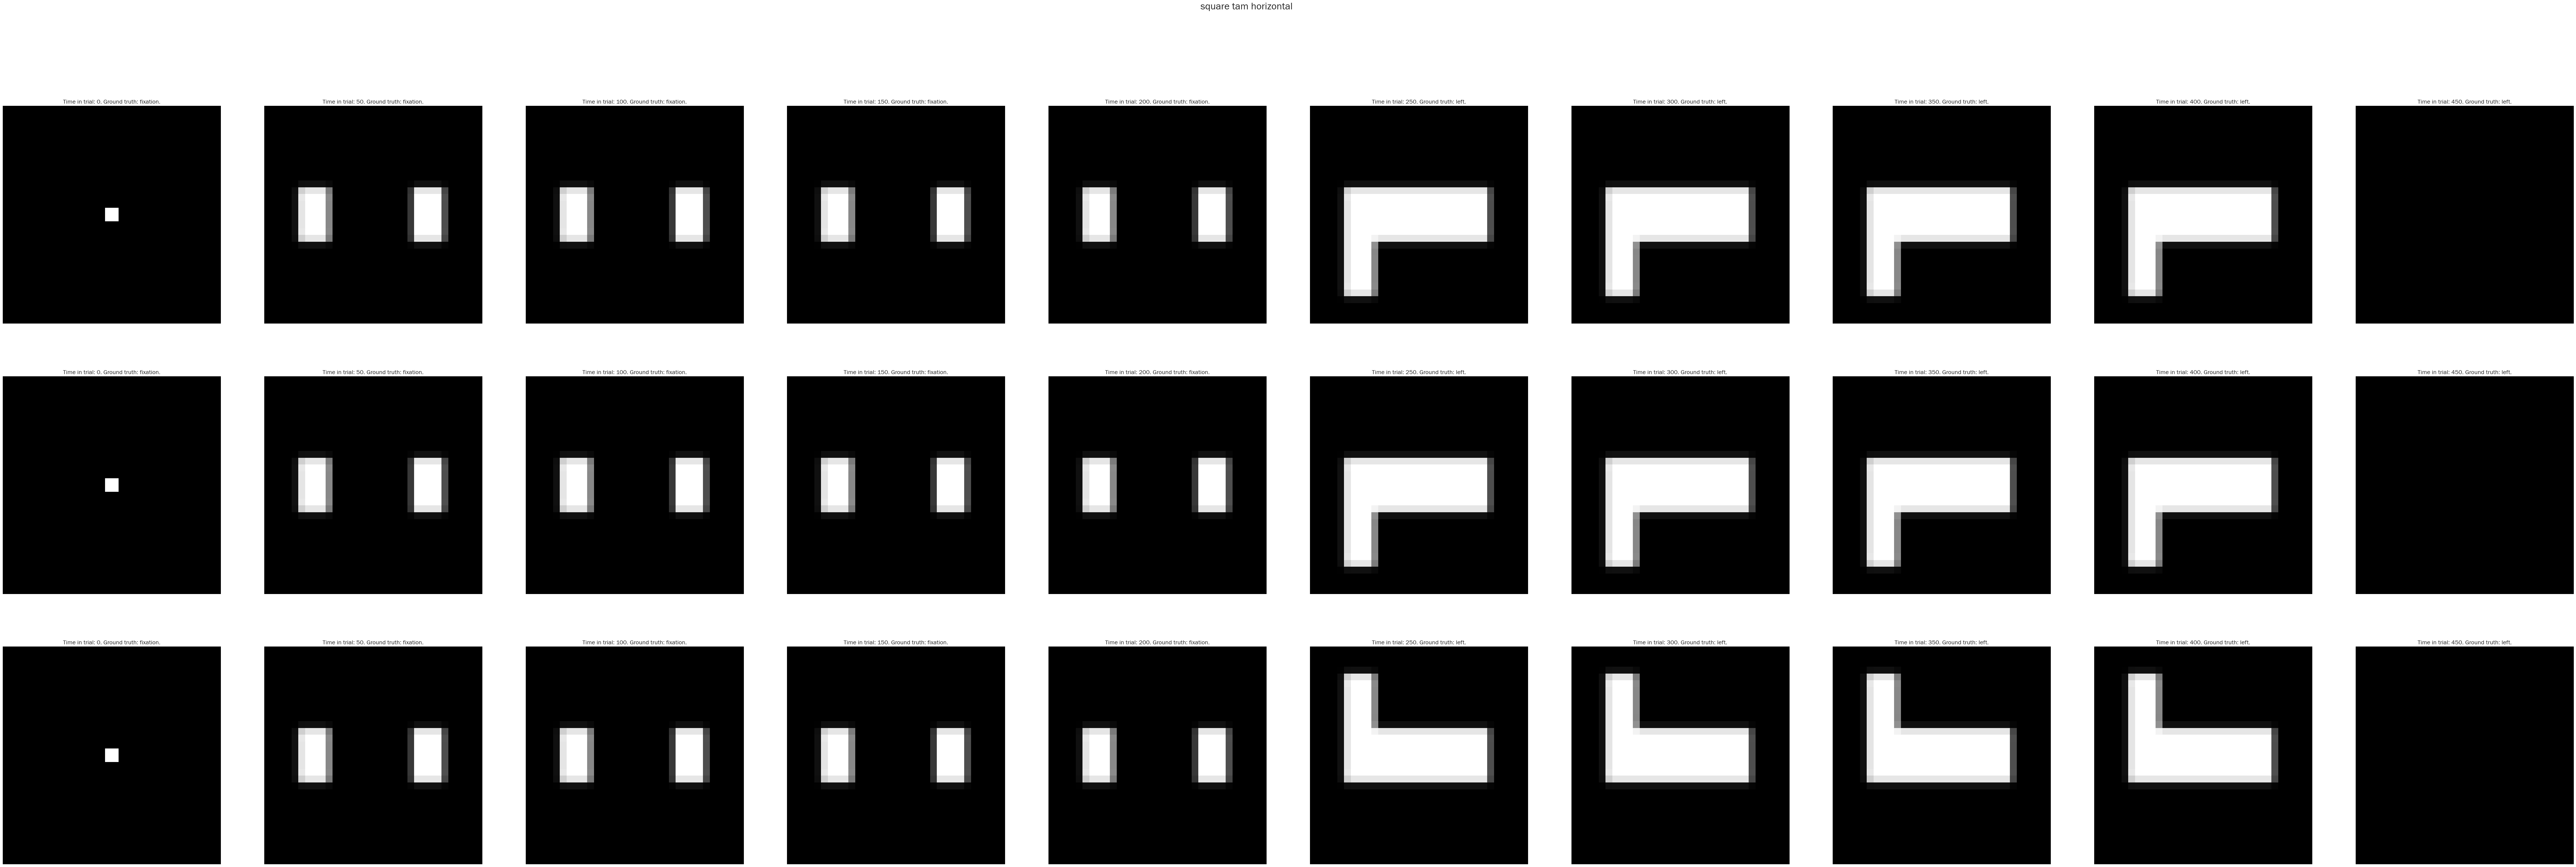

In [754]:
plot_dataset(3, training_datasets["square-horizontal"])

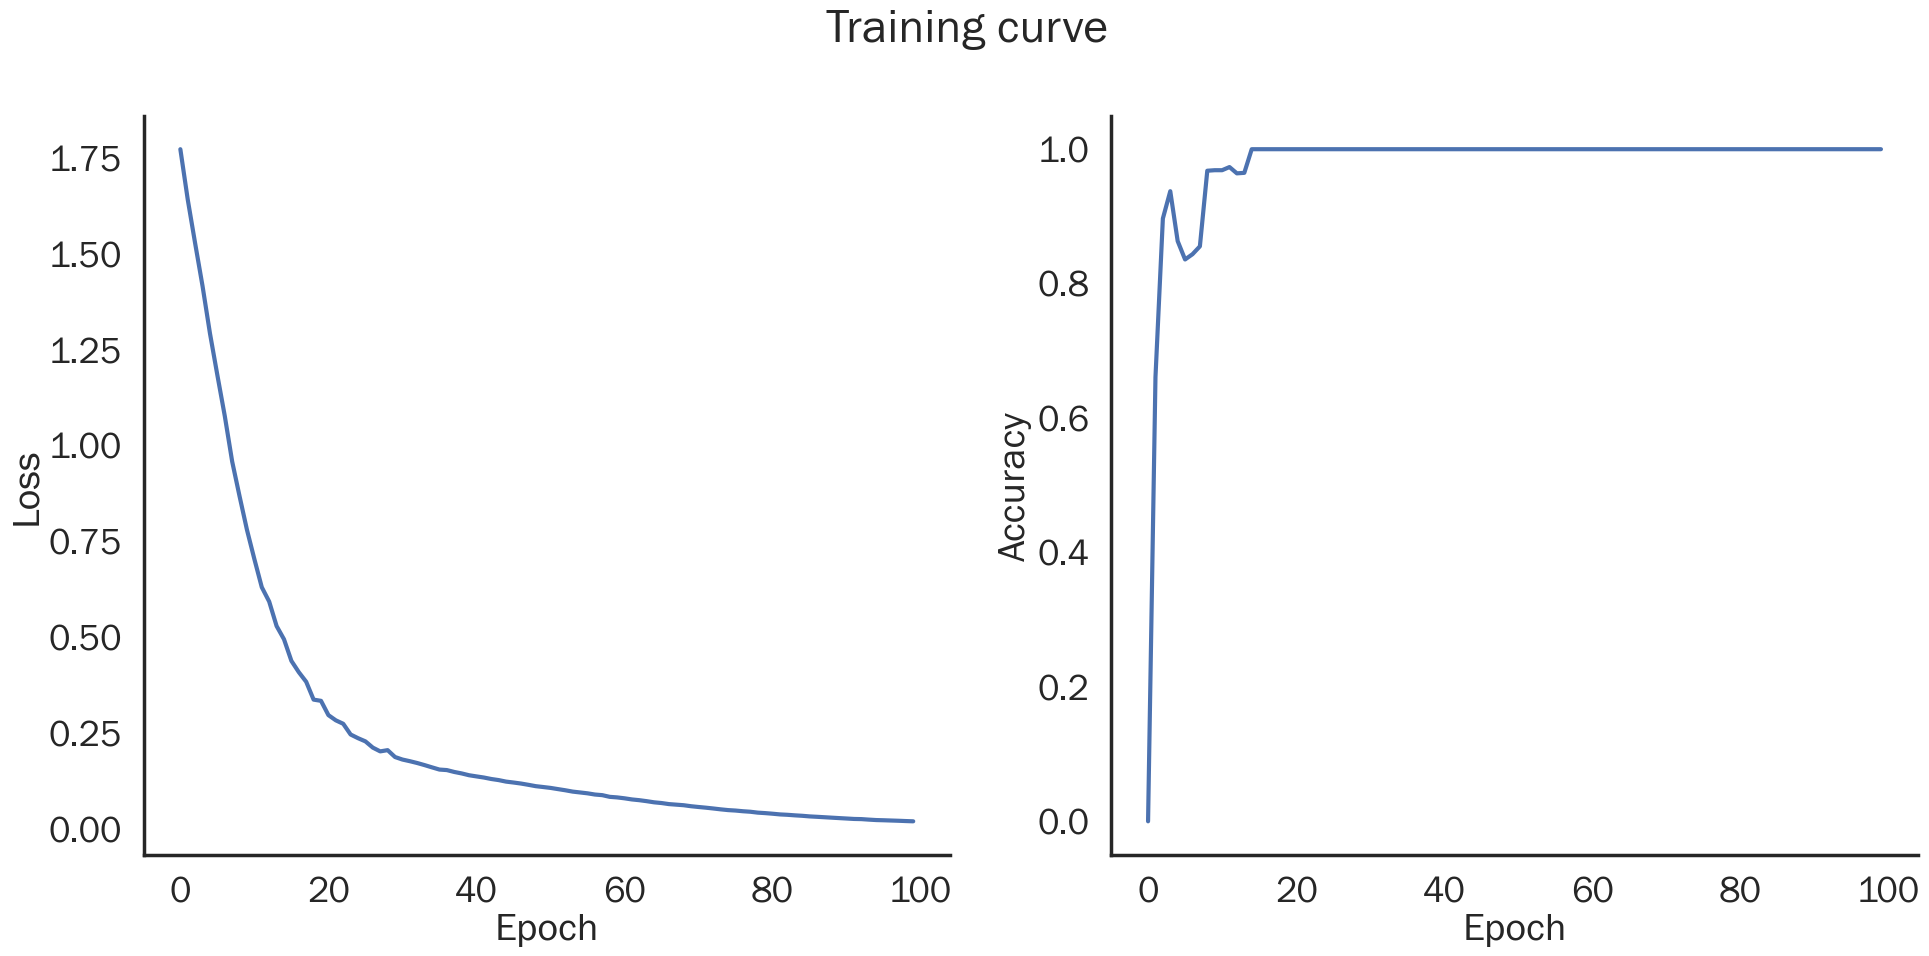

In [662]:
# Plot learning curve
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Training curve")
ax[0].plot(train_loss[:100])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
# ax[0].set_title('Training loss')
ax[1].plot(train_acc[:100])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
# ax[1].set_title('Training accuracy')
plt.tight_layout()
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_training_curve.png')
plt.show()

# Plot test accuracy

In [332]:
test_accuracies

defaultdict(None,
            {'square-tam-horizontal': 1.0,
             'square-outline-horizontal': 1.0,
             'circle-tam-horizontal': 0.79,
             'circle-outline-horizontal': 0.73,
             'triangle-tam-horizontal': 0.79,
             'triangle-outline-horizontal': 0.61})

In [343]:
accuracy_labels = {
    "Square Shape": test_accuracies["square-tam-horizontal"],
    "Square Outline": test_accuracies["square-outline-horizontal"],
    "Triangle Shape": test_accuracies["triangle-tam-horizontal"],
    "Triangle Outline": test_accuracies["triangle-outline-horizontal"],
    "Circle Shape": test_accuracies["circle-tam-horizontal"],
    "Circle Outline": test_accuracies["circle-outline-horizontal"],
}

C:\Users\shari\AppData\Local\Temp\ipykernel_92896\117994184.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Greys')


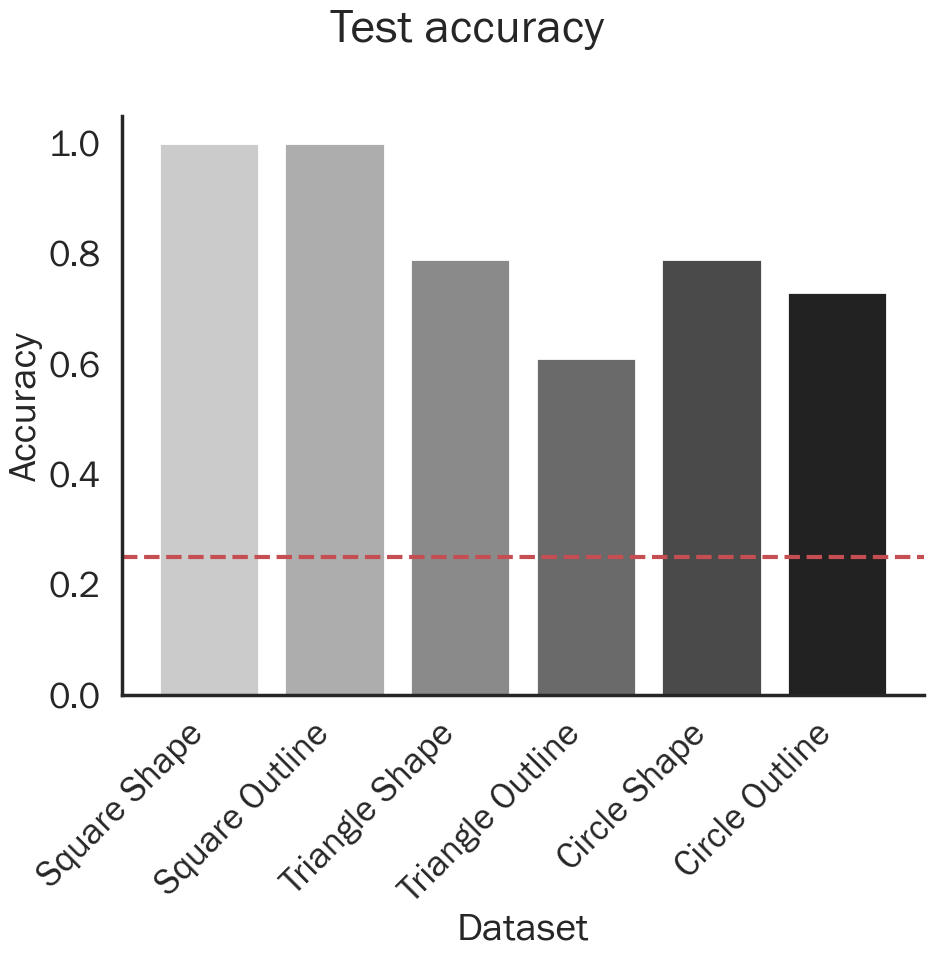

In [668]:
# Plot test accuracy
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
fig.suptitle("Test accuracy")

n_values = len(list(accuracy_labels.values()))

# Create a colormap
cmap = cm.get_cmap('Greys')

# Compute the color for each bar
colors = [cmap((i+1)/(n_values+1) * 0.8 + 0.2) for i in range(n_values)]
#
# for et, acc in accuracy_labels.items():
#     ax.bar(et, acc, color=colors)
#     # Rotate x-axis labels
#     plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

ax.bar(accuracy_labels.keys(), accuracy_labels.values(), color=colors)
plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_xlabel('Dataset')
ax.set_ylabel('Accuracy')
ax.axhline(y=0.25, color='r', linestyle='--')
# ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_test_accuracy.png')

# PCA on hidden layer

In [806]:
activity = test_activities["square-tam-horizontal"]
all_activity = np.concatenate(list(activity), axis=0)


In [379]:
# Define PCA to extract 2 components
pca = PCA(n_components=2)
activity = test_activities["square-tam-horizontal"]

# Concatenate activity for PCA
all_activity = np.concatenate(list(activity), axis=0)
print("Shape of the original activity: (Number of trials, )", activity.shape)
print("Shape of each trial's activity: (Trial time points, Neurons)", activity[0].shape)
print('Shape of the concatenated activity: (Time points, Neurons): ', all_activity.shape)

# Run PCA on the concatenated data data
pca.fit(all_activity)  # activity (Time points, Neurons)

# Find the transform to low-dimension
activity_pc = pca.transform(all_activity)
print('Shape of the projected activity: (Time points, PCs): ', activity_pc.shape)

# Save important variables
n_trials = activity.shape[0]
n_timepoints = activity[0].shape[0]
n_all_neurons = activity[0].shape[1]

print('Number of trials: ', n_trials)
print('Number of time points: ', n_timepoints)
print('Number of neurons: ', n_all_neurons)

Shape of the original activity: (Number of trials, ) (100,)
Shape of each trial's activity: (Trial time points, Neurons) (10, 256)
Shape of the concatenated activity: (Time points, Neurons):  (1000, 256)
Shape of the projected activity: (Time points, PCs):  (1000, 2)
Number of trials:  100
Number of time points:  10
Number of neurons:  256


In [376]:
test_activities["square-tam-horizontal"][0].shape

(10, 256)

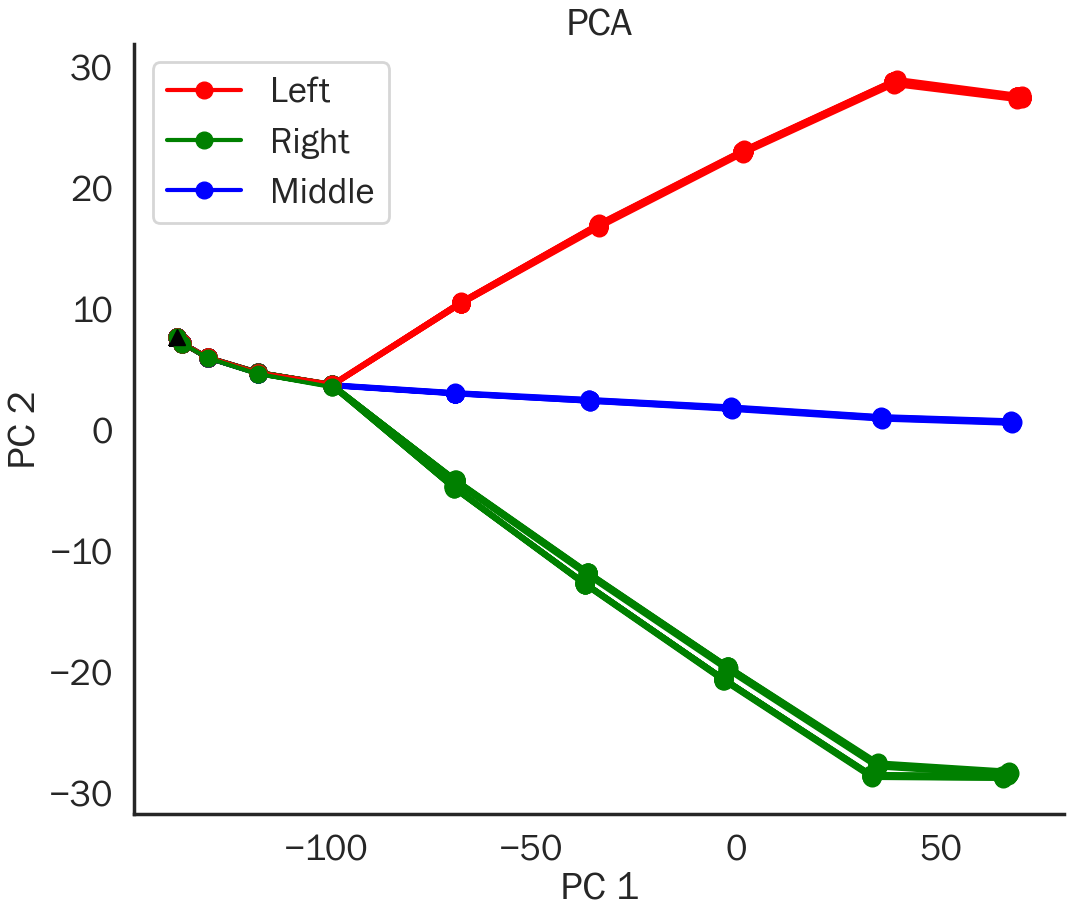

In [669]:
fig, ax = plt.subplots(figsize=(12, 10))
trial_infos = infos["square-tam-horizontal"]

# Create empty lists to hold legend handles and labels
handles = []
labels = []

# Go through trials
for t in range(n_trials):

    # Transform each trial
    activity_pc = pca.transform(activity[t])  # (Time points, PCs)

    # Select this trial's ground truth
    trial = trial_infos[t]
    if trial['ground_truth'] == 1:
        motion = 'Left'
        color = 'red'
    elif trial['ground_truth'] == 2:
        motion = 'Middle'
        color = 'blue'
    elif trial["ground_truth"] == 3:
        motion = 'Right'
        color='green'

    # Plot the PC activity
    p, = ax.plot(activity_pc[:, 0], activity_pc[:, 1], 'o-', color=color)

    # If this is the first time this type of motion is plotted, add it to the legend
    if motion not in labels:
        handles.append(p)
        labels.append(motion)

    # Plot the beginning of a trial with a special symbol
    _ = ax.plot(activity_pc[0, 0], activity_pc[0, 1], '^', color='black')

# Add a legend using the handles and labels lists
plt.legend(handles, labels)

# Change names
ax.set_title(f'PCA')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')

plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca.png')

# PCA on individual bins

In [480]:
# Binning time points
n_bins = 3
bin_size = n_timepoints // n_bins
bins = np.histogram(np.arange(n_timepoints), n_bins)
bin_edges = np.floor(bins[1]).astype(int)

# Define PCA with 2 components
n_comps = 2
pca = PCA(n_components=n_comps)

# Initiate variables to keep track of top PCA neurons
n_top = 10  # number of top neurons with the highest weights in PCA
top_neurons = np.zeros((n_comps, n_top, n_bins))

# Loop through time bins
for i, tb in enumerate(bin_edges[:-1]):

    # Select activity across all trials and neurons for only this time bin
    bin_activity = np.concatenate([ac[tb: tb + bin_size] for ac in activity], axis=0)

    # Run PCA
    pca.fit(bin_activity)

    # Extract loadings
    loadings = pca.components_

    # Get index of top k neurons
    for pc in range(n_comps):
        neurons = np.argpartition(loadings[pc], -n_top)[-n_top:]
        top_neurons[pc, :, i] = neurons

In [483]:
# Gather the data from neurons of interest in a dataframe for easier plotting
data = {"NEURON":[], "TRIAL": [], "TIMEPOINT": [], "ACTIVITY": [], "TRIAL_TYPE": []}

# Find the highest activity neurons (without duplicates)
neurons = np.unique(top_neurons.flatten()).astype(int)

# Get the timeseries of activities
for n, neuron in enumerate(neurons):

    # Find the timeseries of activity of this neuron in all trials
    for trial in range(n_trials):
        for tp in range(n_timepoints):

            ac = activity[trial][tp, neuron]

            # Save to data
            data["NEURON"].append(neuron)
            data["TRIAL"].append(trial + 1)
            data["TIMEPOINT"].append(tp + 1)
            data["ACTIVITY"].append(ac)

            if trial_infos[trial]["ground_truth"] == 1:
                tt = "Right"
            elif trial_infos[trial]["ground_truth"] == 2:
                tt = "Mid"
            else:
                tt = "Left"
            data["TRIAL_TYPE"].append(tt)

# Turn into dataframe
df = pd.DataFrame(data)
df.head()

,NEURON,TRIAL,TIMEPOINT,ACTIVITY,TRIAL_TYPE
0,6,1,1,0.373582,Right
1,6,1,2,1.034658,Right
2,6,1,3,1.889024,Right
3,6,1,4,2.586343,Right
4,6,1,5,2.913949,Right


In [484]:
neurons.shape

(46,)

C:\Users\shari\AppData\Local\Temp\ipykernel_92896\2945089108.py:43: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_xticklabels(x_ticks)


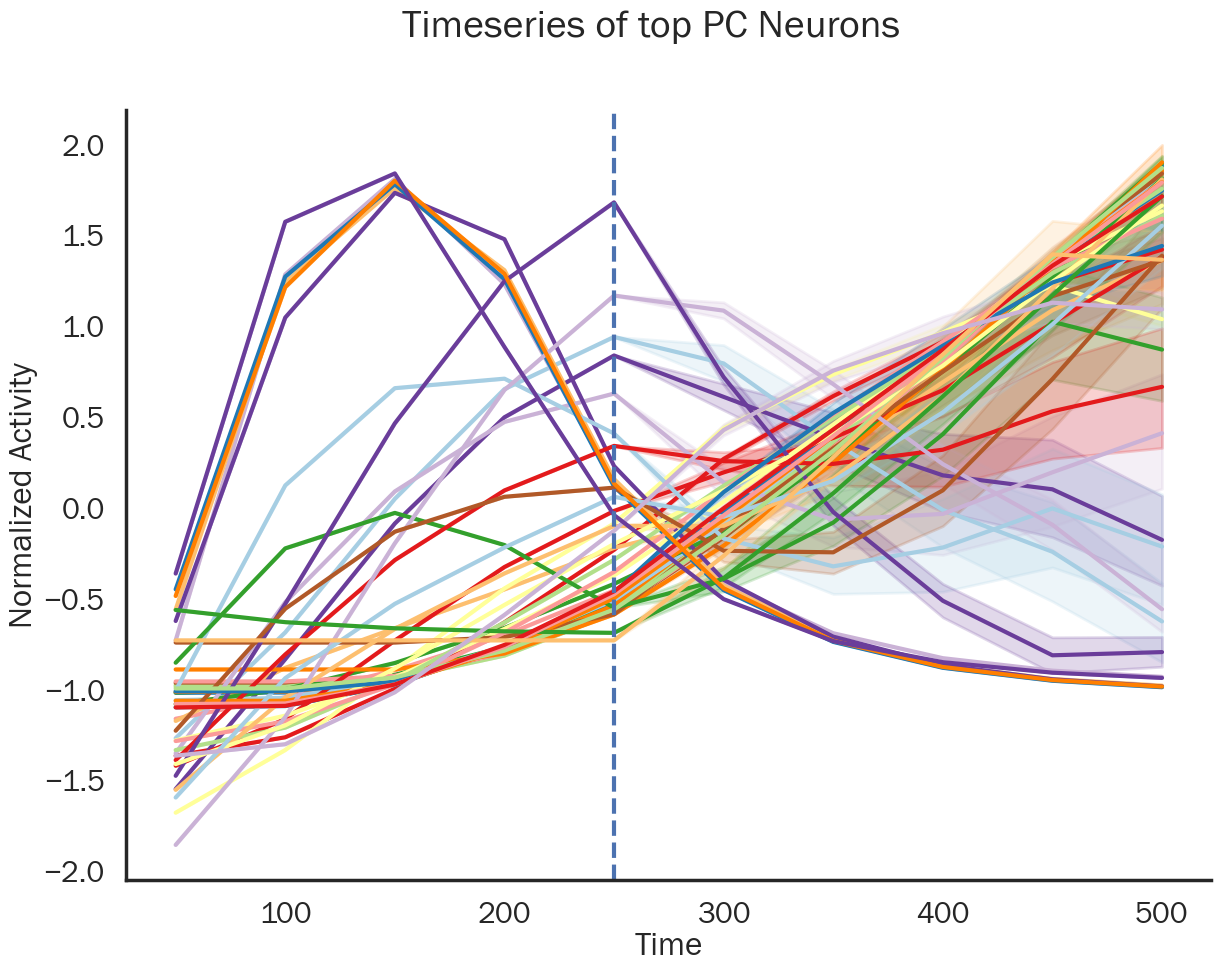

In [752]:
# Visualizing the activity of highest-loading neurons
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
custom_pal = sns.color_palette("Paired", len(df.NEURON.unique()))
fig.suptitle("Timeseries of top PC Neurons")

# Change title
# ax.set_title(f"Timeseries of top PC Neurons")

# Normalize activity
plt_df = df.copy()
for neuron in neurons:
    plt_df.loc[df.NEURON == neuron, "ACTIVITY"] = zscore(plt_df.loc[df.NEURON == neuron, "ACTIVITY"])

# # Plot the actual activity
# _plot = sns.lineplot(
#     data=df,
#     x="TIMEPOINT",
#     y="ACTIVITY",
#     hue="NEURON",
#     palette=custom_pal,
#     ax=axes[0]
# )
# axes[0].set_ylabel("Firing rate")
# _plot.legend_.remove()


# Plot the normalized activity
_plot = sns.lineplot(
    data=plt_df,
    x="TIMEPOINT",
    y="ACTIVITY",
    hue="NEURON",
    palette=custom_pal,
    ax=axes
)
axes.set_ylabel("Normalized Activity")
_plot.legend_.remove()

# Change properties
# for i in range(2):
axes.set_xlabel("Time")
x_ticks = np.arange(0, 550, 100)
axes.set_xticklabels(x_ticks)
axes.axvline(x=5, color='b', ls='--')

plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_timeseries.png')

# RSA

In [543]:
def reshape_activity_for_rsa(activity, condition):
    # Select activity for this condition
    cond_activity = activity[condition]

    # Average across trials
    cond_activity = np.mean(cond_activity, axis=0)

    # Stack across timepoints
    cond_activity = cond_activity.reshape(-1)

    return cond_activity

In [544]:
# Construct a time point by neuron matrix (T, N) but only for times after 300ms (6th time point)
conditions = df.TRIAL_TYPE.unique()
n_conditions = len(conditions)
n_neurons = len(neurons)
n_trials = 100
cutoff = 5
slc_activity = np.zeros((n_conditions, n_trials, (n_timepoints - cutoff), n_neurons))

for trial in range(n_trials):
    for n, neuron in enumerate(neurons):
        ac = activity[trial][cutoff:, neuron]
        ac = zscore(ac, axis=0, ddof=1)
        slc_activity[int(trial_infos[trial]["ground_truth"]) - 1, trial, :, n] = ac

# Compute correlation vectors to get (N, N) matrices for each condition
rdm = np.zeros((n_conditions, n_conditions))

for cond_one in range(n_conditions):

        # Select activity for this condition
        cond_one_activity = reshape_activity_for_rsa(slc_activity, cond_one)

        # second conditino
        for cond_two in range(n_conditions):

            # Select activity for this condition
            cond_two_activity = reshape_activity_for_rsa(slc_activity, cond_two)

            # Compute correlation matrix
            rdm[cond_one, cond_two] = 1 - np.corrcoef(cond_one_activity, cond_two_activity)[0, 1]

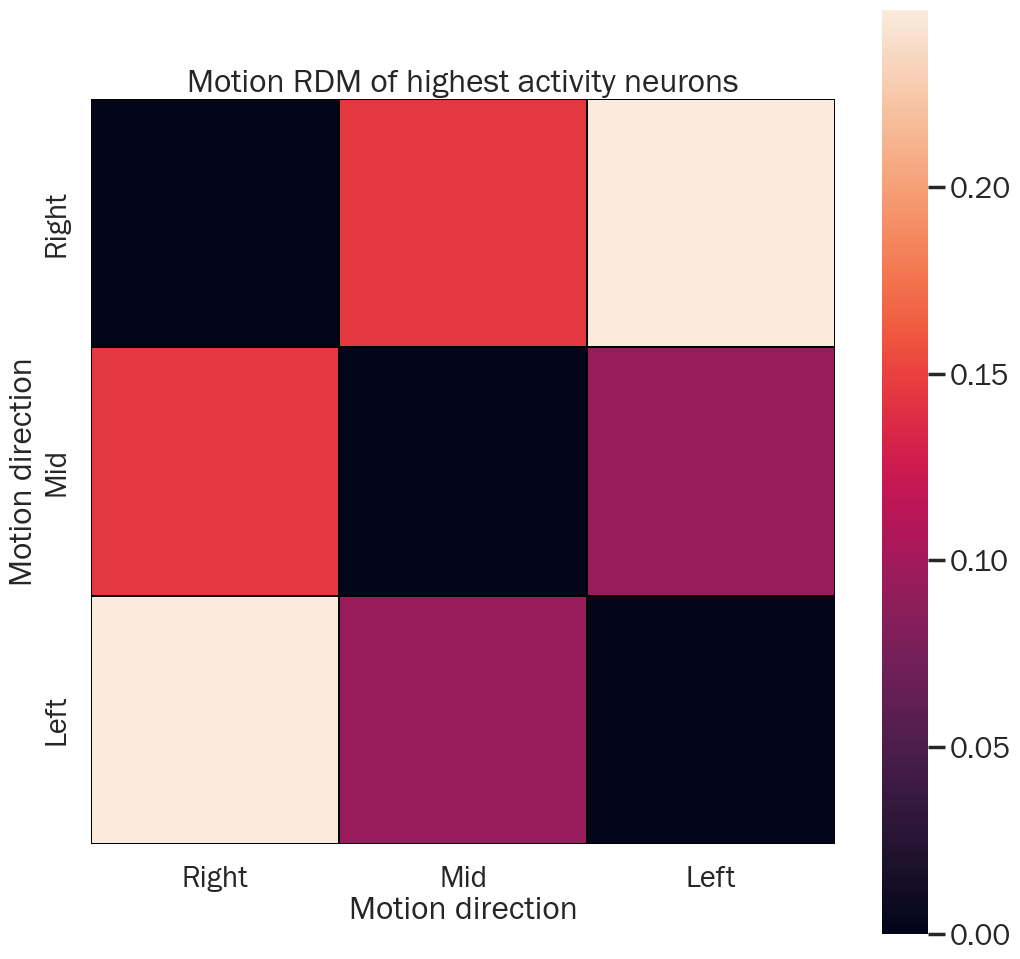

In [840]:
# Plot the neural RDMS
fig, ax = plt.subplots(figsize=(12, 12))
condition_names = ["Right", "Mid", "Left"]

# plot
_plot = sns.heatmap(
    data=rdm,
    linewidths=.1,
    linecolor='black',
    square=True,
    # cmap="YlGnBu",
    ax=ax,
    xticklabels=condition_names,
    yticklabels=condition_names
)

ax.set_title("Motion RDM of highest activity neurons")
ax.set_xlabel("Motion direction")
ax.set_ylabel("Motion direction")
plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_rdm.png')

# Agglomerative clustering

In [488]:
neurons = np.unique(top_neurons.flatten()).astype(int)
data = np.zeros((len(neurons), n_trials * n_timepoints))
all_ac = np.stack(activity)

# Get the timeseries of activities
for n, neuron in enumerate(neurons):

    # Find the timeseries of activity of this neuron in all trials
    for trial in range(n_trials):
        for tp in range(n_timepoints):

            data[n, trial + tp] = all_ac[trial, tp, neuron]

In [702]:
from scipy.cluster import hierarchy
from sklearn.preprocessing import StandardScaler


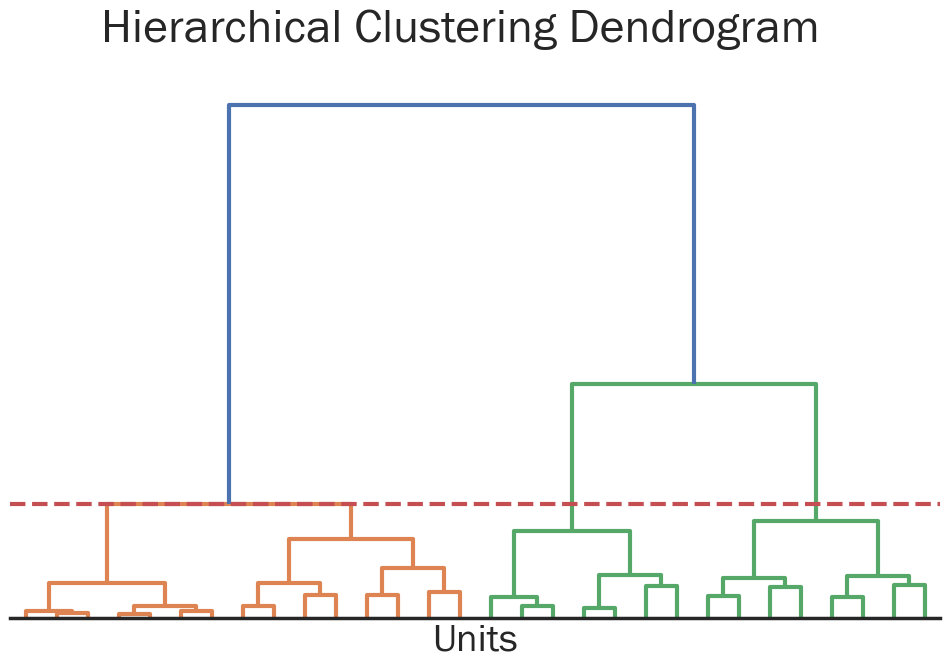

In [674]:
# Assuming your data is in an array called "data"
data = np.stack(activity)

# # Reshape your data such that each neuron's activity is a single vector
X = data.reshape(-1, data.shape[-1])

# Perform Agglomerative Clustering
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(X.T)

# Create linkage matrix for dendrogram
counts = np.zeros(clustering.children_.shape[0])
n_samples = len(clustering.labels_)
for i, merge in enumerate(clustering.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([clustering.children_, clustering.distances_, counts]).astype(float)

# Plot the dendrogram
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Hierarchical Clustering Dendrogram')

# Create a dendrogram using the linkage matrix
dendrogram = hierarchy.dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=4)

# Determine the cut-off distance that will result in a specific number of clusters
num_clusters = 4  # the number of clusters you want
cut_off_distance = clustering.distances_[-(num_clusters-1)]

# Draw a horizontal line to cut dendrogram
ax.axhline(y=cut_off_distance, color='r', linestyle='--')
# Remove x ticks
ax.set_xticks([])
ax.set_xlabel('Units')
ax.set_ylabel('Distance')

# Remove spines
# for spine in ax.spines.values():
#     spine.set_visible(False)
# remove y spine
ax.spines["left"].set_visible(False)

# Remove y axis
ax.yaxis.set_visible(False)
plt.show()

fig.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_dendrogram.png')

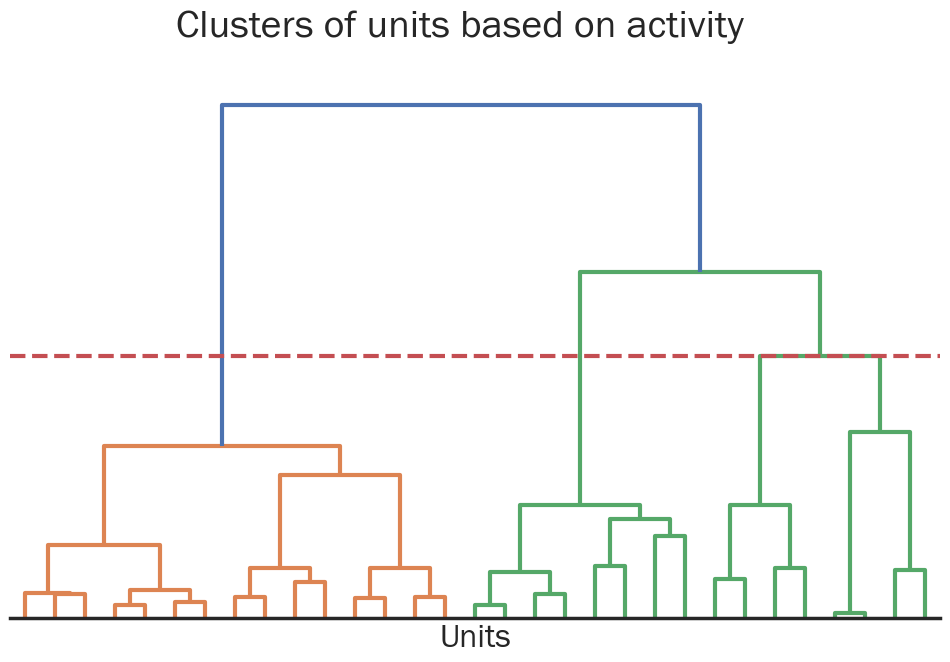

In [746]:
# Assuming your data is in an array called "data"
data = np.stack(activity)

# # Reshape your data such that each neuron's activity is a single vector
X = data.reshape(-1, data.shape[-1])
# Initialize a StandardScaler
scaler = StandardScaler()

# Scale the data
data_scaled = scaler.fit_transform(X.T)

# Perform Agglomerative Clustering
clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(data_scaled)

# Create linkage matrix for dendrogram
counts = np.zeros(clustering.children_.shape[0])
n_samples = len(clustering.labels_)
for i, merge in enumerate(clustering.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([clustering.children_, clustering.distances_, counts]).astype(float)

# Plot the dendrogram
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Clusters of units based on activity')

# Create a dendrogram using the linkage matrix
dendrogram = hierarchy.dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=4)

# Determine the cut-off distance that will result in a specific number of clusters
num_clusters = 4  # the number of clusters you want
cut_off_distance = clustering.distances_[-(num_clusters-1)]

# Draw a horizontal line to cut dendrogram
ax.axhline(y=cut_off_distance, color='r', linestyle='--')
# Remove x ticks
ax.set_xticks([])
ax.set_xlabel('Units')
ax.set_ylabel('Distance')

# Remove spines
# for spine in ax.spines.values():
#     spine.set_visible(False)
# remove y spine
ax.spines["left"].set_visible(False)

# Remove y axis
ax.yaxis.set_visible(False)
plt.show()

fig.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_dendrogram.png')

C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\2087843982.py:54: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(np.arange(0, 501, 100))


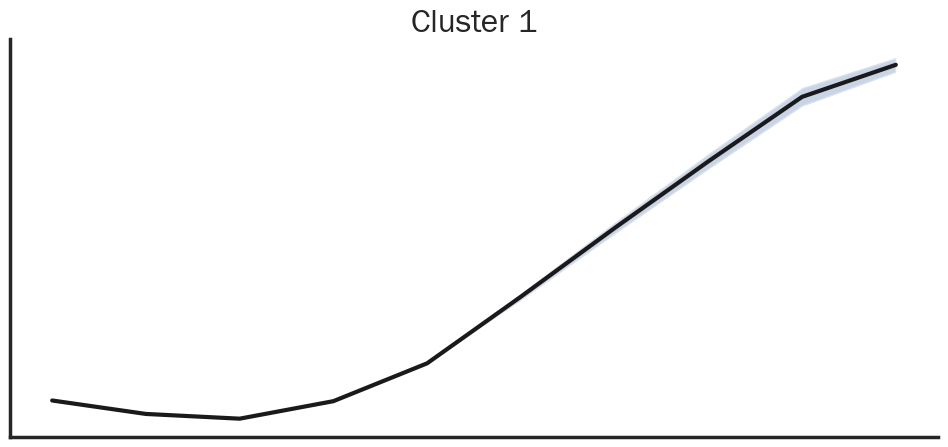

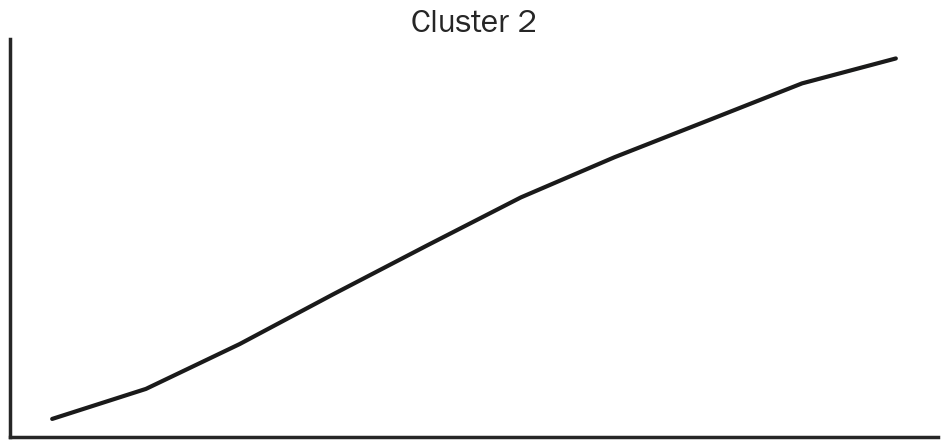

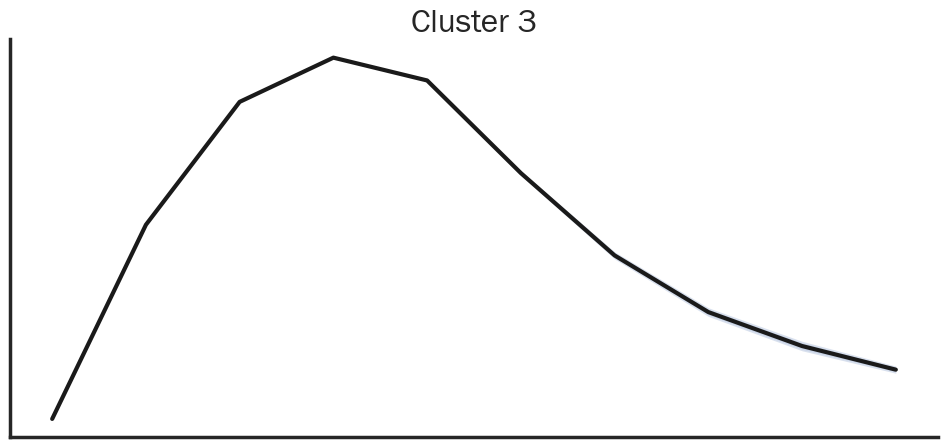

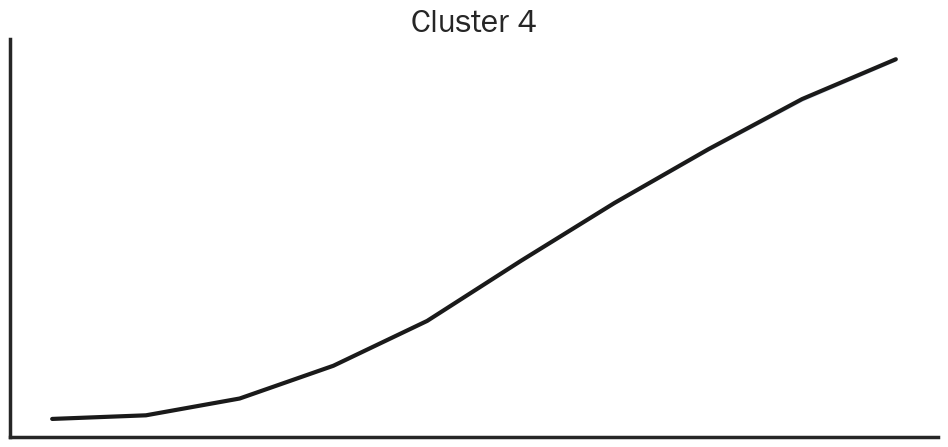

In [862]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Initialize a StandardScaler
scaler = StandardScaler()
data = np.stack(activity)
# Reshape data to (n_neurons, n_trials*n_timepoints)
data_reshaped = data.transpose(2, 0, 1).reshape(256, -1)

# Scale the data
data_scaled = scaler.fit_transform(data_reshaped)

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster.fit_predict(data_scaled)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Initialize a figure with multiple subplots

# Iterate over the clusters
for idx, (cluster, neuron_indices) in enumerate(cluster_dict.items()):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    # Get the corresponding data for the neurons in this cluster
    cluster_data = data[:, :, neuron_indices]

    # Compute the average timecourse
    avg_timecourse = cluster_data.mean(axis=0).mean(axis=1)

    # Compute the standard error of the mean across trials
    sem_timecourse = cluster_data.std(axis=0).mean(axis=1) / np.sqrt(n_trials)

    # Plot the average timecourse on its own subplot
    ax.plot(avg_timecourse, color="k")

    # Plot the error bands
    ax.fill_between(range(n_timepoints), avg_timecourse - sem_timecourse, avg_timecourse + sem_timecourse, alpha=0.3)

    ax.set_title(f"Cluster {cluster + 1}")

    # Add explicit xticklabels from 0 to 500 ms
    ax.set_xticklabels(np.arange(0, 501, 100))

    # Add xlabel
    ax.set_xlabel('')
    ax.set_xticklabels([])

    # Add ylabel
    ax.set_ylabel('')
    ax.set_yticklabels([])

    # Add line at 300ms
    # ax.axvline(x=4, color='r', linestyle='--')

    # Show the plot
    plt.tight_layout()
    plt.show()

    # save
    fig.savefig(str(FIG_DIR / f'TAM-basic_TAM-all_cluster{idx+1}.png'))




C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\4154250328.py:53: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(np.arange(0, 501, 100))


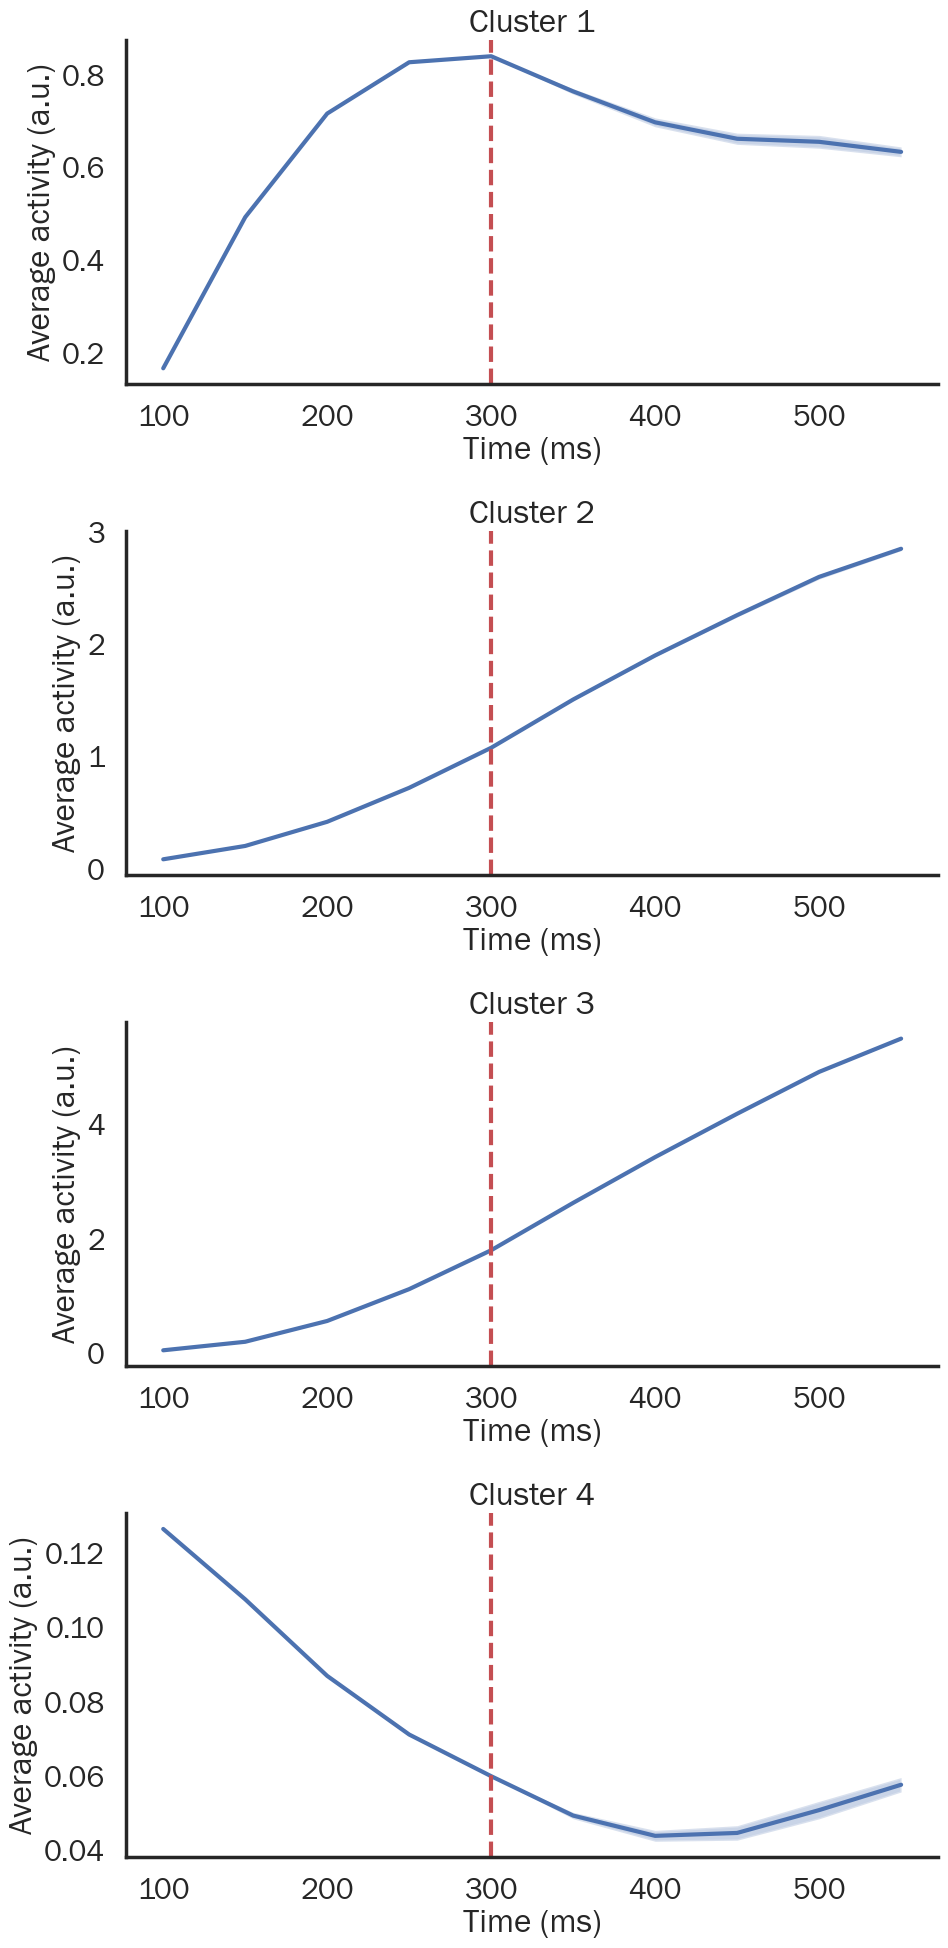

In [857]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Initialize a StandardScaler
scaler = StandardScaler()
data = np.stack(activity)
# Reshape data to (n_neurons, n_trials*n_timepoints)
data_reshaped = data.transpose(2, 0, 1).reshape(256, -1)

# Scale the data
# data_scaled = scaler.fit_transform(data_reshaped)

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster.fit_predict(data_reshaped)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Initialize a figure with multiple subplots
fig, axs = plt.subplots(len(unique_labels), 1, figsize=(10, len(unique_labels)*5))

# Iterate over the clusters
for idx, (cluster, neuron_indices) in enumerate(cluster_dict.items()):
    # Get the corresponding data for the neurons in this cluster
    cluster_data = data[:, :, neuron_indices]

    # Compute the average timecourse
    avg_timecourse = cluster_data.mean(axis=0).mean(axis=1)

    # Compute the standard error of the mean across trials
    sem_timecourse = cluster_data.std(axis=0).mean(axis=1) / np.sqrt(n_trials)

    # Plot the average timecourse on its own subplot
    axs[idx].plot(avg_timecourse)

    # Plot the error bands
    axs[idx].fill_between(range(n_timepoints), avg_timecourse - sem_timecourse, avg_timecourse + sem_timecourse, alpha=0.3)

    axs[idx].set_title(f"Cluster {cluster + 1}")

    # Add explicit xticklabels from 0 to 500 ms
    axs[idx].set_xticklabels(np.arange(0, 501, 100))

    # Add xlabel
    axs[idx].set_xlabel('Time (ms)')

    # Add ylabel
    axs[idx].set_ylabel('Average activity (a.u.)')

    # Add line at 300ms
    axs[idx].axvline(x=4, color='r', linestyle='--')

# Show the plot
plt.tight_layout()
plt.show()


In [770]:
condition_indices

[1,
 3,
 7,
 9,
 12,
 14,
 19,
 21,
 22,
 23,
 25,
 31,
 32,
 33,
 37,
 39,
 43,
 44,
 45,
 46,
 49,
 53,
 54,
 55,
 59,
 61,
 63,
 64,
 69,
 71,
 74,
 76,
 77,
 78,
 79,
 82,
 83,
 85,
 87,
 96,
 99]

In [788]:
avg_timecourse.shape

(10,)

C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\1547518723.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[idx].set_xticklabels(np.arange(0, 501, 100))


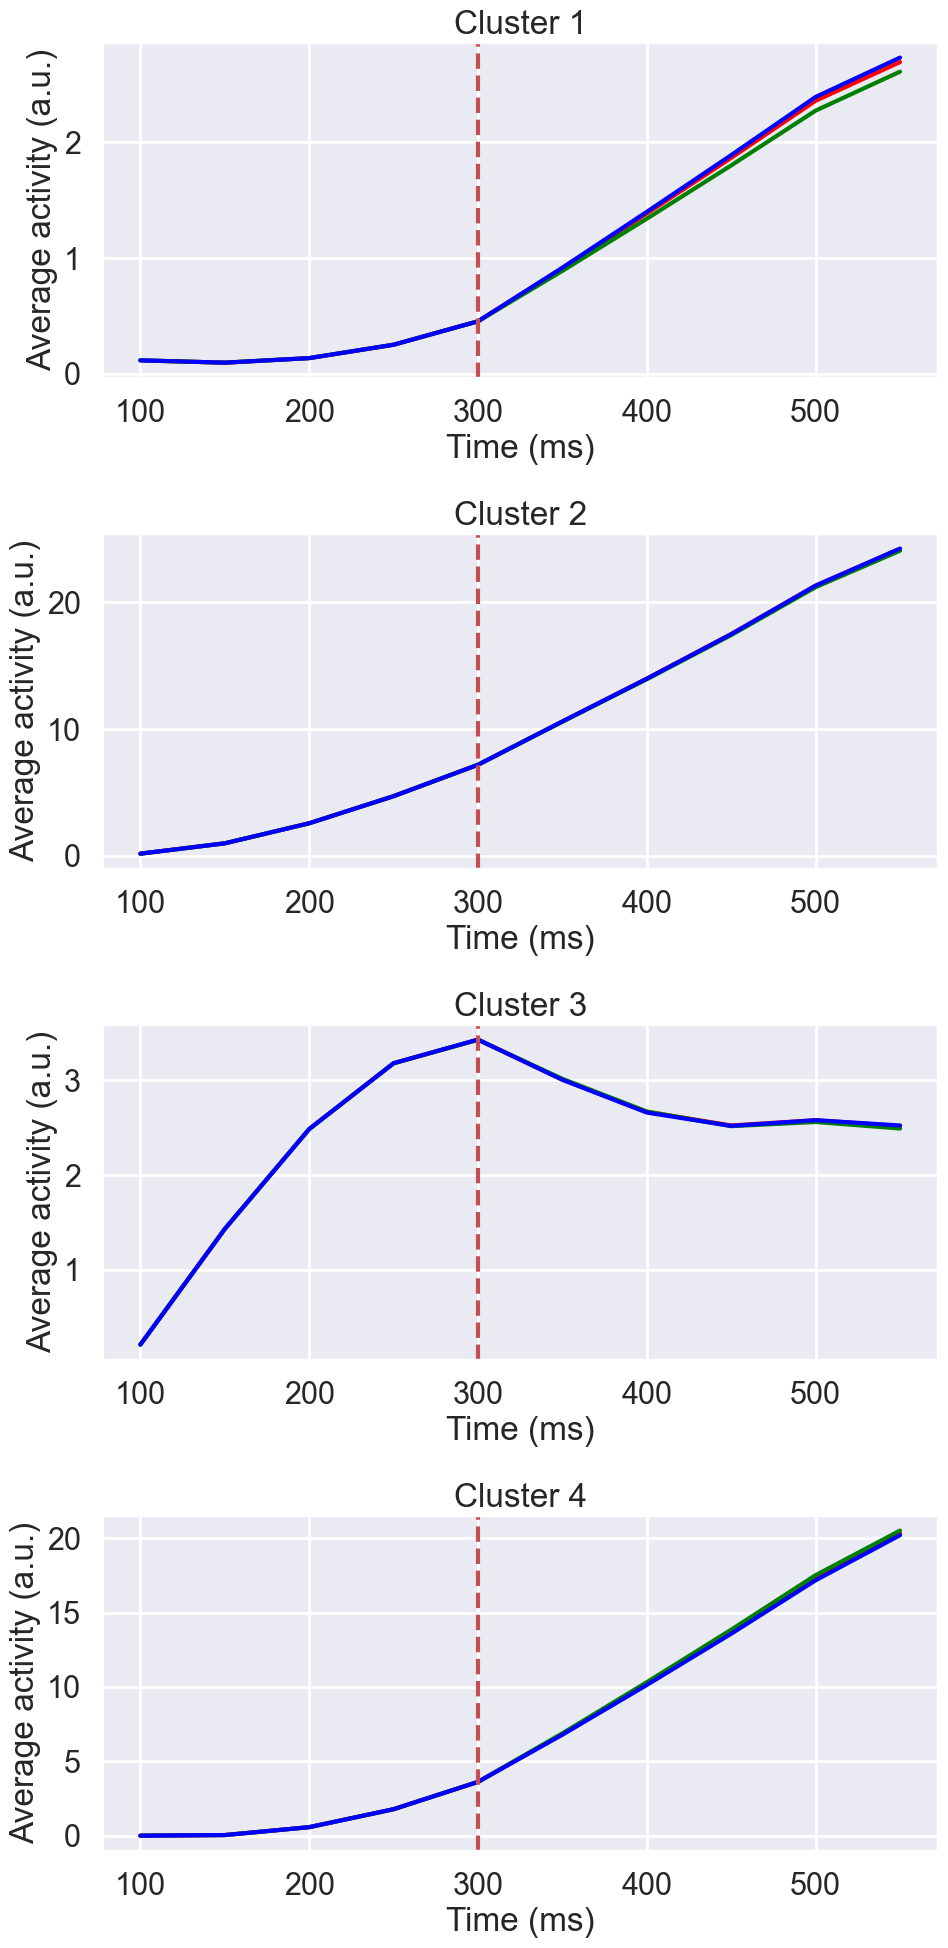

In [808]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Initialize a StandardScaler
scaler = StandardScaler()

# Define your trial conditions and corresponding colors
trial_conditions = [1, 2, 3]
colors = ['red', 'green', 'blue']
color_map = dict(zip(trial_conditions, colors))

# Reshape data to (n_neurons, n_trials*n_timepoints)
data = np.stack(activity)
data_reshaped = data.transpose(2, 0, 1).reshape(256, -1)
# data_reshaped = data_reshaped[df.NEURON.unique(), :]
# Scale the data
# data_scaled = scaler.fit_transform(data_reshaped)

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster.fit_predict(data_scaled)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Initialize a figure with multiple subplots
fig, axs = plt.subplots(len(unique_labels), 1, figsize=(10, len(unique_labels)*5))

# Iterate over the clusters
for idx, (cluster, neuron_indices) in enumerate(cluster_dict.items()):
    # Get the corresponding data for the neurons in this cluster
    cluster_data = data[:, :, neuron_indices]

    # Compute the average timecourse for each condition
    for condition in trial_conditions:
        # Get the indices of trials for this condition
        condition_indices = [i for i, trial_info in enumerate(trial_infos) if trial_info["ground_truth"] == condition]

        # Get the corresponding data for these trials
        condition_data = cluster_data[condition_indices, :, :]

        # Compute the average timecourse and the standard error of the mean
        avg_timecourse = condition_data.mean(axis=2).mean(axis=0)
        # avg_timecourse = condition_data[0, :, 0]
        # sem_timecourse = condition_data.std(axis=0).mean(axis=1) / np.sqrt(len(condition_indices))

        # Plot the average timecourse and error bands with the corresponding color
        axs[idx].plot(avg_timecourse, color=color_map[condition])
        # axs[idx].fill_between(range(n_timepoints), avg_timecourse - sem_timecourse, avg_timecourse + sem_timecourse, color=color_map[condition], alpha=0.3)

        axs[idx].set_title(f"Cluster {cluster + 1}")

    # Add explicit xticklabels from 0 to 500 ms
    axs[idx].set_xticklabels(np.arange(0, 501, 100))

    # Add xlabel
    axs[idx].set_xlabel('Time (ms)')

    # Add ylabel
    axs[idx].set_ylabel('Average activity (a.u.)')

    # Add line at 300ms
    axs[idx].axvline(x=4, color='r', linestyle='--')

# Show the plot
plt.tight_layout()
plt.show()


In [750]:
print(df.NEURON.unique())

[  6  11  15  17  24  32  34  37  41  48  55  63  68  80  84 104 119 121
 128 129 135 139 151 153 154 157 159 162 167 168 175 177 178 179 191 197
 205 213 217 218 222 232 238 241 251 253]


C:\Users\shari\AppData\Local\Temp\ipykernel_92896\609316219.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\609316219.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\609316219.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\609316219.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)


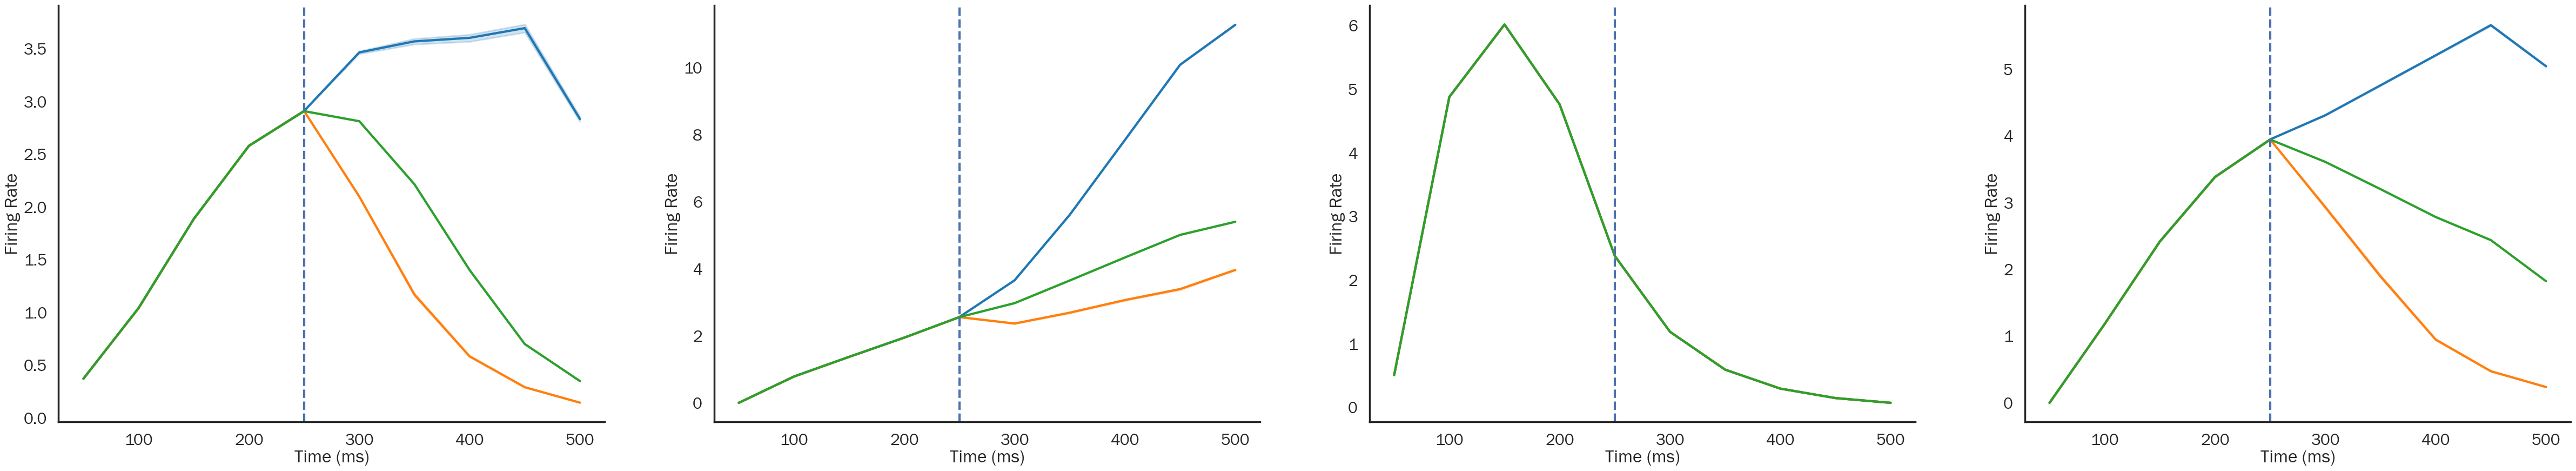

In [758]:
# Visualizing the activity of highest-loading neurons based on
# fig, axes = plt.subplots(len(neurons), 1, figsize=(10, 8 * len(df.NEURON.unique())))
nus = df.NEURON.unique()
fig, axes = plt.subplots(1, 4, figsize=(60, 10))
custom_pal = sns.color_palette("Paired", 3)

# Start plotting
for n, neuron in enumerate([0, 6, 8, 9]):
    neuron = nus[neuron]
    # Select axis
    ax = axes[n]

    # Select data and normalize
    _df = df[df.NEURON == neuron]
    # _df.ACTIVITY = zscore(_df.ACTIVITY)

    # Plot
    _plot = sns.lineplot(
        data=_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        # palette='tab10',
        ax=ax
    )

    # Vertical line at the 6th timepoint
    ax.axvline(x=5, color='b', ls='--')

    # Change properties
    ax.set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    ax.set_xticklabels(x_ticks)

    ax.set_ylabel("Firing Rate")

    # Remove legend
    # ax.get_legend().remove()
# save_dir = ROOT / "figures" / f"timecourse_top_{neurons.shape[0]}_neurons_v{model_version}_{stim_type}.png"
# fig.savefig(str(save_dir))

C:\Users\shari\AppData\Local\Temp\ipykernel_92896\883611314.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\883611314.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)


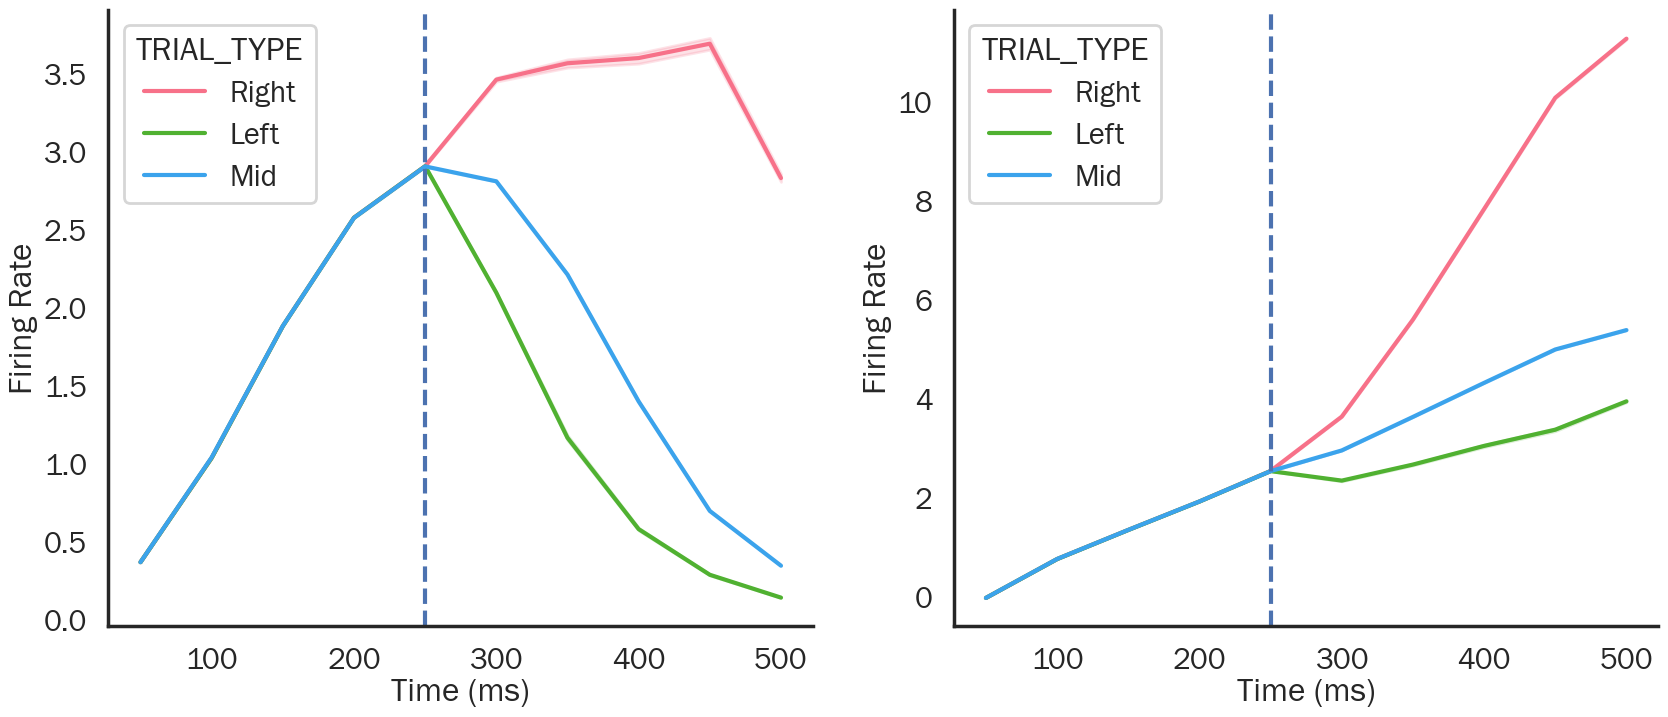

In [765]:
# Visualizing the activity of highest-loading neurons based on
# fig, axes = plt.subplots(len(neurons), 1, figsize=(10, 8 * len(df.NEURON.unique())))
nus = df.NEURON.unique()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
custom_pal = sns.color_palette("Paired", 3)

# Start plotting
for n, neuron in enumerate([0, 6]):
    neuron = nus[neuron]
    # Select axis
    ax = axes[n]

    # Select data and normalize
    _df = df[df.NEURON == neuron]
    # _df.ACTIVITY = zscore(_df.ACTIVITY)

    # Plot
    _plot = sns.lineplot(
        data=_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        palette='husl',
        ax=ax
    )

    # Vertical line at the 6th timepoint
    ax.axvline(x=5, color='b', ls='--')

    # Change properties
    ax.set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    ax.set_xticklabels(x_ticks)

    ax.set_ylabel("Firing Rate")

    # Remove legend
    # ax.get_legend().remove()
save_dir = ROOT / "figures" / f"timecourse_top_by_condition_1.png"
fig.savefig(str(save_dir))

C:\Users\shari\AppData\Local\Temp\ipykernel_92896\1188180664.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\1188180664.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x_ticks)


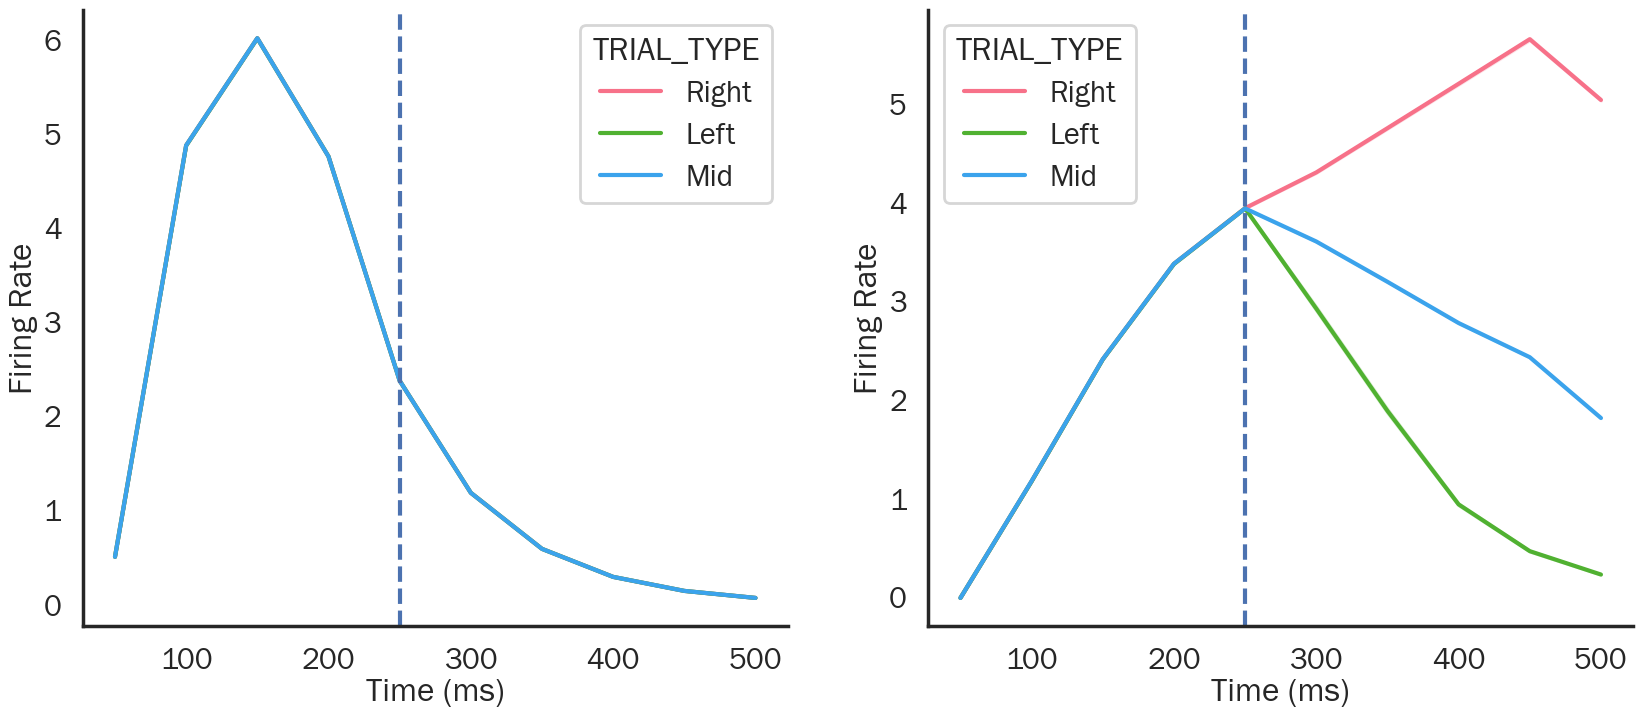

In [766]:
# Visualizing the activity of highest-loading neurons based on
# fig, axes = plt.subplots(len(neurons), 1, figsize=(10, 8 * len(df.NEURON.unique())))
nus = df.NEURON.unique()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
custom_pal = sns.color_palette("Paired", 3)

# Start plotting
for n, neuron in enumerate([8, 9]):
    neuron = nus[neuron]
    # Select axis
    ax = axes[n]

    # Select data and normalize
    _df = df[df.NEURON == neuron]
    # _df.ACTIVITY = zscore(_df.ACTIVITY)

    # Plot
    _plot = sns.lineplot(
        data=_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        palette='husl',
        ax=ax
    )

    # Vertical line at the 6th timepoint
    ax.axvline(x=5, color='b', ls='--')

    # Change properties
    ax.set_xlabel("Time (ms)")
    x_ticks = np.arange(0, 550, 100)
    ax.set_xticklabels(x_ticks)

    ax.set_ylabel("Firing Rate")

    # Remove legend
    # ax.get_legend().remove()
save_dir = ROOT / "figures" / f"timecourse_top_by_condition_2.png"
fig.savefig(str(save_dir))

In [767]:
print(ROOT / "figures" )

C:\Users\shari\projects\illusion-rnn\figures


In [809]:
from sklearn.cluster import AgglomerativeClustering

# Reshape data to (n_trials*n_timepoints, n_neurons)
data = np.stack(activity)
# data_reshaped = data.reshape(1000, 256)
data_reshaped = data.reshape(-1, data.shape[-1])

# Perform Agglomerative Clustering
cluster = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster.fit_predict(data_reshaped.T)  # transpose to get shape (n_neurons, n_samples)

# Get the unique labels (clusters)
unique_labels = np.unique(cluster.labels_)

# Create a dictionary to store the neuron indices for each cluster
cluster_dict = {}

# Iterate over unique labels
for label in unique_labels:
    # Get the indices of neurons belonging to this cluster
    neuron_indices = np.where(cluster.labels_ == label)[0]
    # Store the indices in the dictionary
    cluster_dict[label] = neuron_indices

# Print the dictionary
for cluster, neuron_indices in cluster_dict.items():
    print(f"Cluster {cluster} includes neurons: {neuron_indices}")

Cluster 0 includes neurons: [  3   7   8   9  28  29  33  42  44  45  47  52  54  55  72  74  75  76
  82  83  84  85  90  95  96  97  98 101 104 119 120 126 129 131 133 138
 143 145 147 152 153 160 165 170 182 183 190 191 195 198 202 213 216 225
 232 234 237 239 244 248 251]
Cluster 1 includes neurons: [  1   2   4   5   6  10  12  13  14  18  20  21  22  23  25  26  27  30
  31  35  36  38  39  40  41  43  46  49  50  51  53  57  58  59  60  62
  66  67  69  71  77  78  79  87  88  89  91  92  93  94  99 100 102 105
 106 107 108 109 110 111 112 113 114 115 118 123 125 127 128 130 132 134
 136 137 139 140 141 142 146 148 149 150 154 155 157 161 164 166 169 172
 173 176 178 179 181 184 186 188 189 192 193 194 196 199 200 203 204 206
 207 208 211 215 219 220 221 223 224 226 229 230 231 233 235 241 242 243
 245 247 249 252 253 254]
Cluster 2 includes neurons: [ 11  15  17  19  24  32  37  61  63  68  80 116 151 159 167 174 177 187
 210 217 222 227 240]
Cluster 3 includes neurons: [  0  1

C:\Users\shari\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [ ]:
df = pd.DataFrame(colums=['Trial Type', "Cluster", 'Time', 'Activity', 'Unit'])
trial_types = []
clusters = []
time = []
activity = []
unit = []

data = np.stack(activity)

for tr in range(data.shape[0]):
    gt = infos[tr]['ground_truth']

    if gt == 1:
        trial_type = 'Left'
    elif gt == 2:
        trial_type = 'Middle'
    elif gt == 3:
        trial_type = 'Right'

    for nu in range(data.shape[2]):
        for cluster, neuron_indices in cluster_dict.items():

            clusters.append(cluster + 1)

            if nu in neuron_indices:
                df.append([trial_type, tp, data[tr, tp, nu], nu])
        df.append([tr, tp, data[tr, tp, nu], nu])

In [851]:
# Gather the data from neurons of interest in a dataframe for easier plotting
data = {"NEURON":[], "TIMEPOINT": [], "ACTIVITY": [], "TRIAL_TYPE": [], "CLUSTER": []}
ac_st = np.stack(activity)

# Find the highest activity neurons (without duplicates)
for cluster, neuron_indices in cluster_dict.items():
    neurons = neuron_indices

    # Get the timeseries of activities
    for n, neuron in enumerate(neurons):

        # Find the timeseries of activity of this neuron in all trials
        for tr in range(n_trials):
            for tp in range(n_timepoints):



                if trial_infos[trial]["ground_truth"] == 1:
                    condition_indices = [i for i, trial_info in enumerate(trial_infos) if trial_info["ground_truth"] == 1]
                    tt = "Right"

                elif trial_infos[trial]["ground_truth"] == 2:
                    tt = "Mid"
                    condition_indices = [i for i, trial_info in enumerate(trial_infos) if trial_info["ground_truth"] == 2]
                else:
                    tt = "Left"
                    condition_indices = [i for i, trial_info in enumerate(trial_infos) if trial_info["ground_truth"] == 3]

                ac = ac_st[np.array(condition_indices), tp, neuron].mean(axis=0)

                # Save to data
                data["NEURON"].append(neuron)
                # data["TRIAL"].append(trial + 1)
                data["TIMEPOINT"].append(tp + 1)
                data["ACTIVITY"].append(ac)
                data["CLUSTER"].append(cluster + 1)
                data["TRIAL_TYPE"].append(tt)

# Turn into dataframe
df = pd.DataFrame(data)
df.head()

,NEURON,TIMEPOINT,ACTIVITY,TRIAL_TYPE,CLUSTER
0,3,1,0.000000,Left,1
1,3,2,0.006988,Left,1
2,3,3,0.216513,Left,1
3,3,4,0.616899,Left,1
4,3,5,1.160281,Left,1


In [852]:
print(df.head())

   NEURON  TIMEPOINT  ACTIVITY TRIAL_TYPE  CLUSTER
0       3          1  0.000000       Left        1
1       3          2  0.006988       Left        1
2       3          3  0.216513       Left        1
3       3          4  0.616899       Left        1
4       3          5  1.160281       Left        1


C:\Users\shari\AppData\Local\Temp\ipykernel_92896\3512387458.py:13: UserWarning: The palette list has more values (256) than needed (1), which may not be intended.
  _plot = sns.lineplot(
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\3512387458.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_xticklabels(x_ticks)
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\3512387458.py:13: UserWarning: The palette list has more values (256) than needed (1), which may not be intended.
  _plot = sns.lineplot(
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\3512387458.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes.set_xticklabels(x_ticks)
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\3512387458.py:13: UserWarning: The palette list has more values (256) than needed (1), which may not be intended.
  _plot = sns.lineplot(
C:\Users\shari\AppData\Local\Temp\ipykernel_92896\3512387458.py:28: UserWarning: Fixed

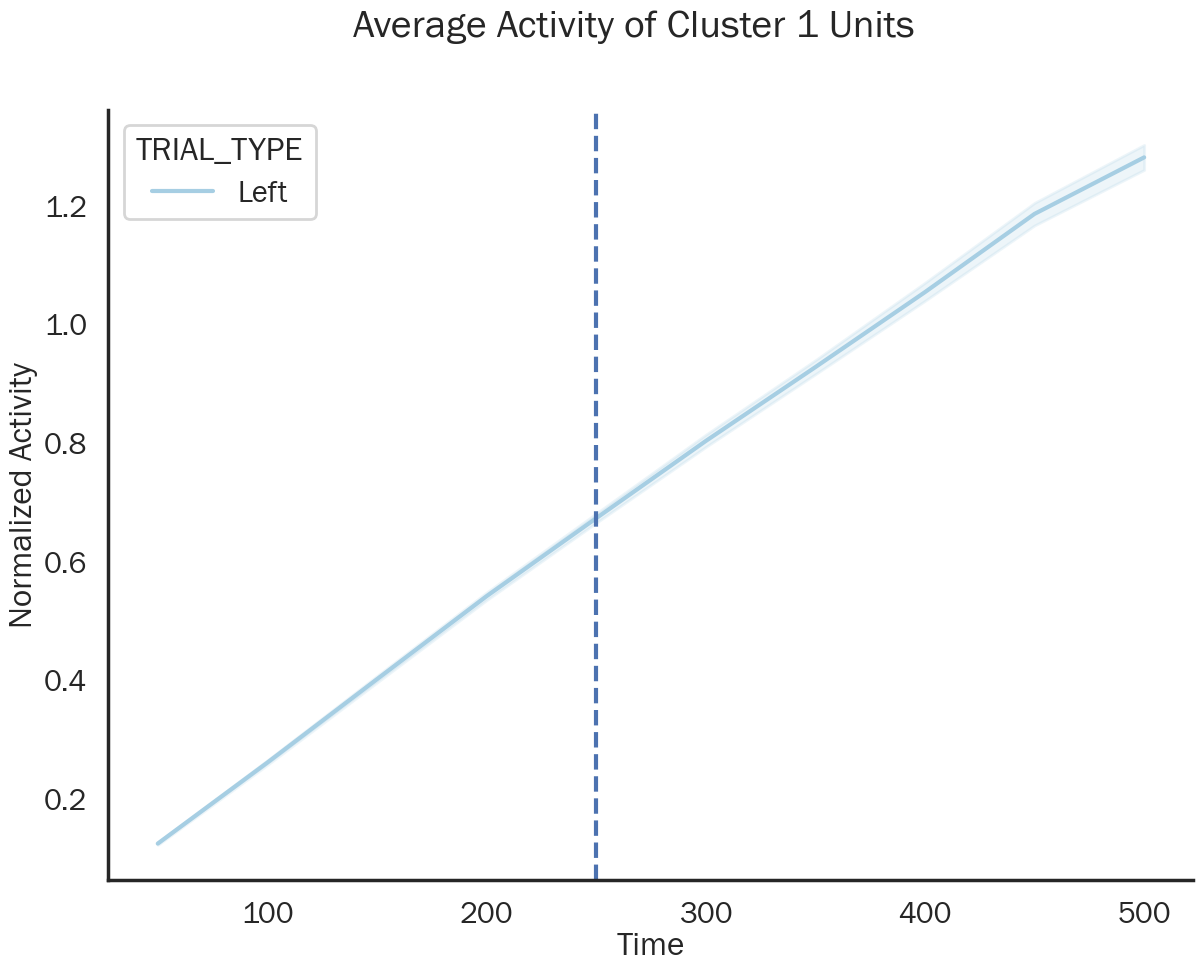

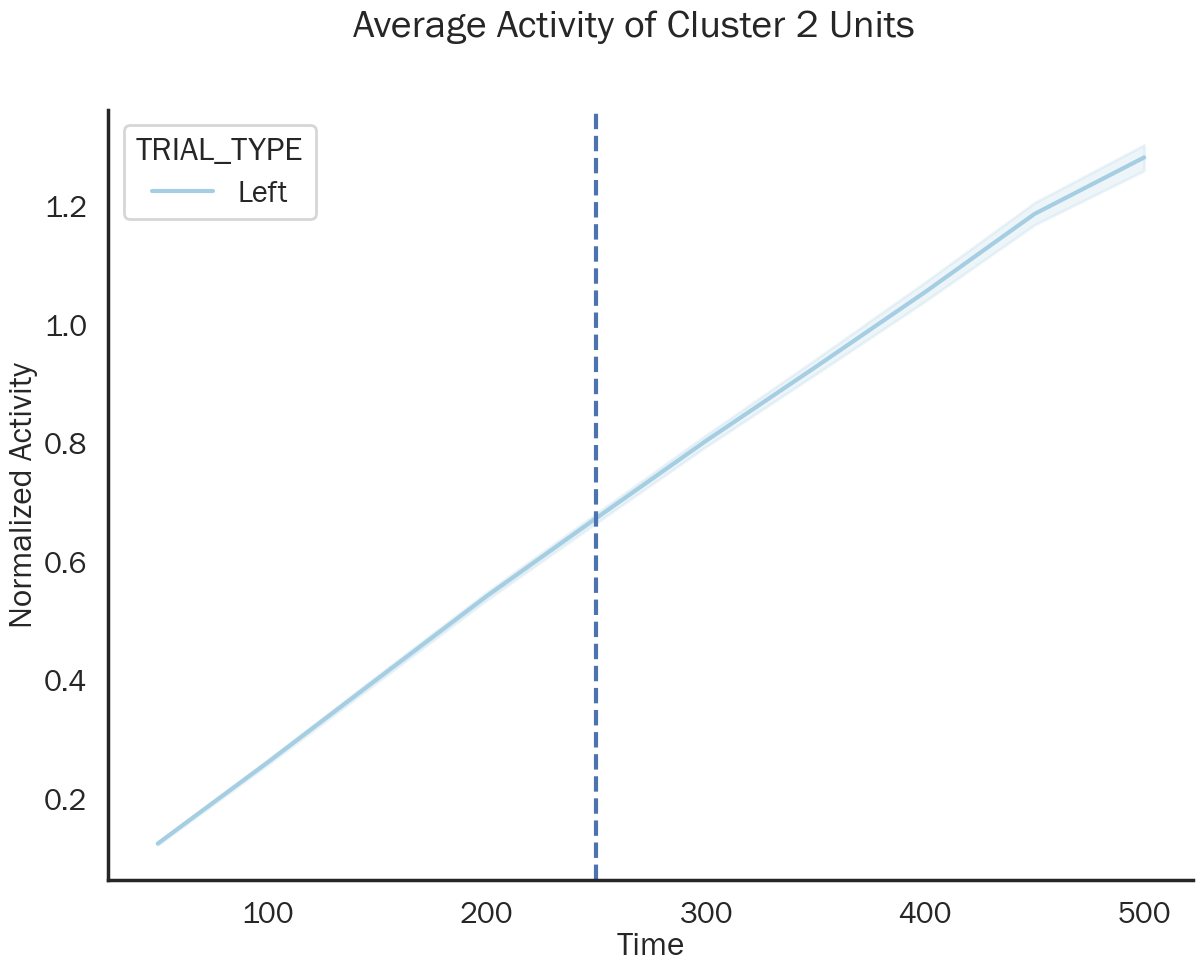

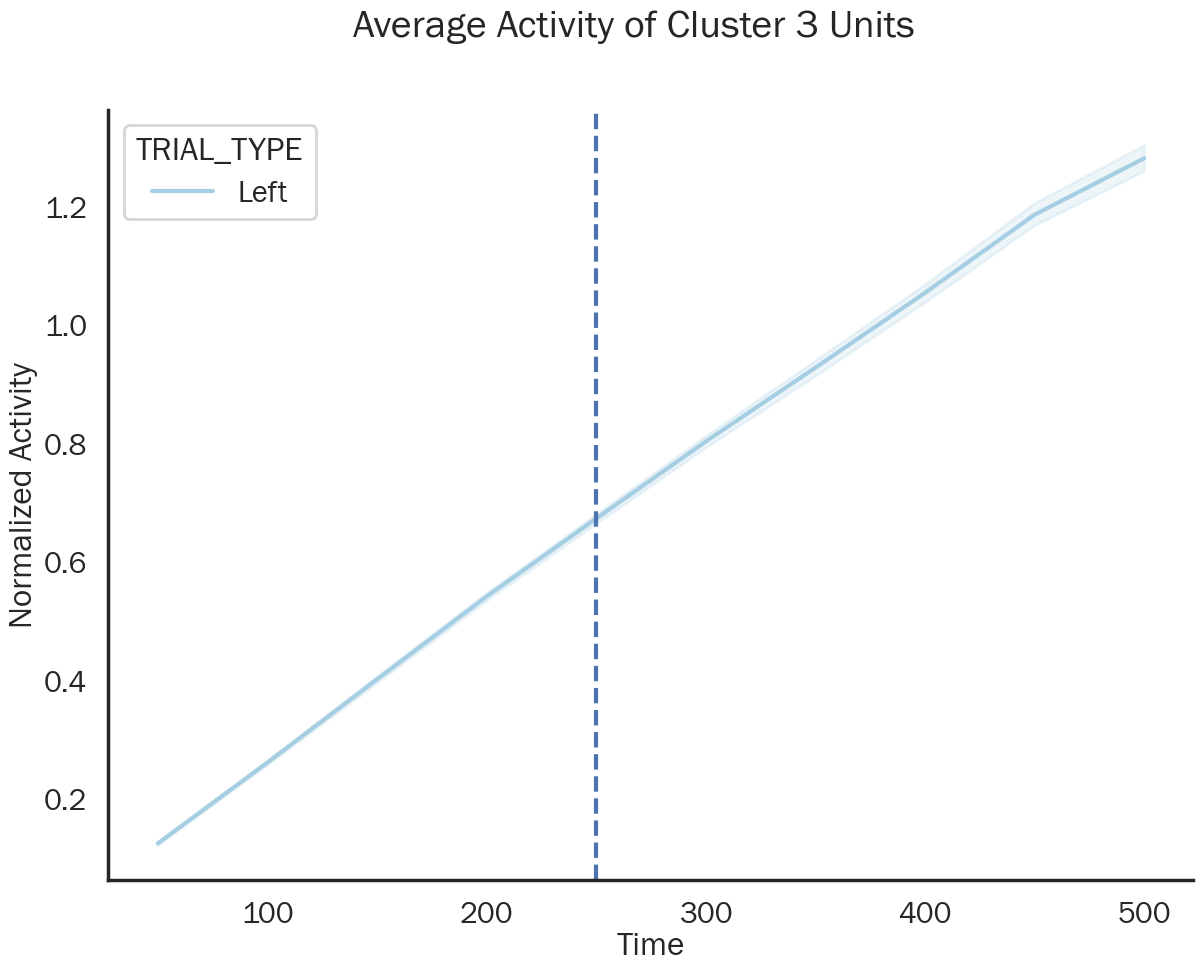

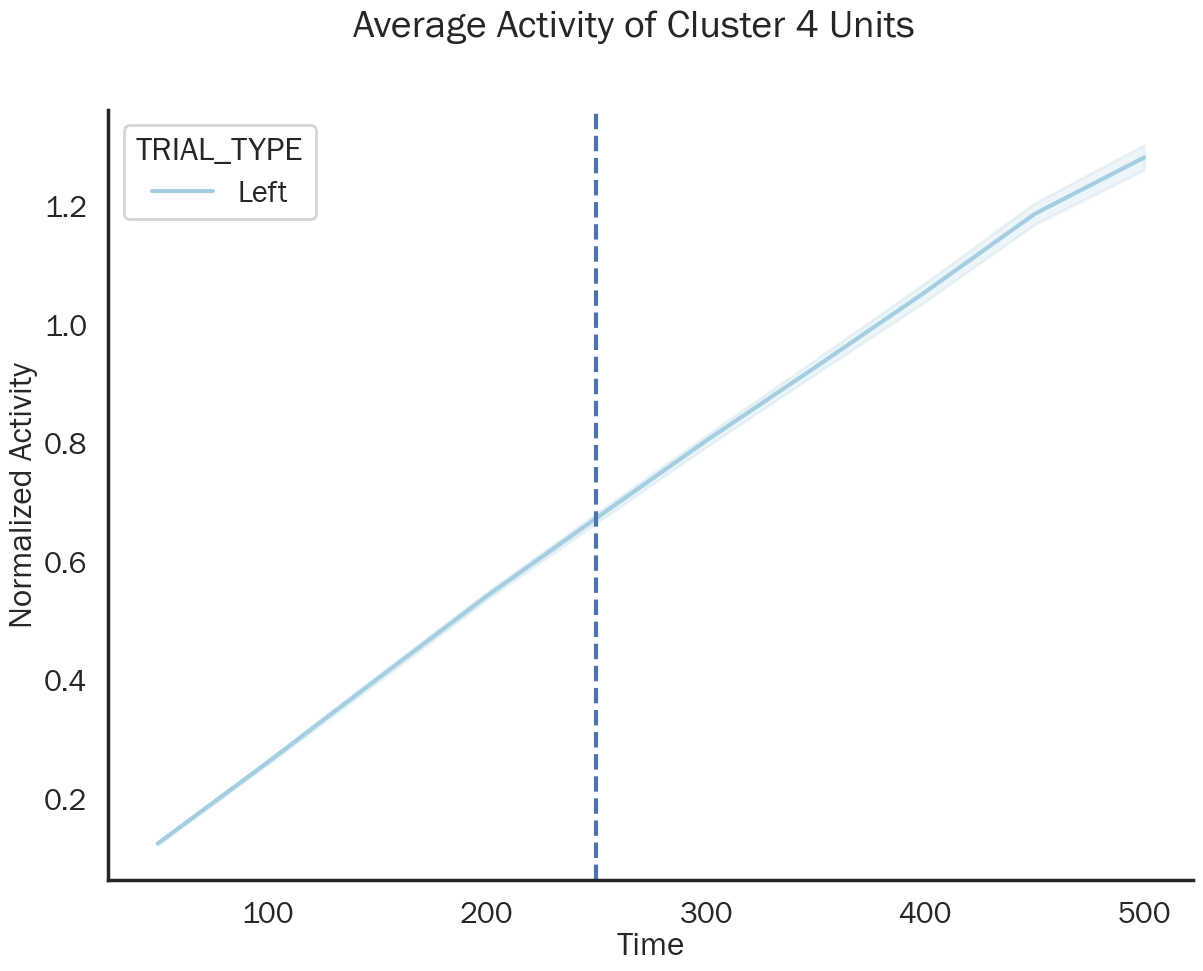

In [853]:
# Visualizing the activity of highest-loading neurons

for cluster in range(1, 5):
    fig, axes = plt.subplots(1, 1, figsize=(14, 10))
    custom_pal = sns.color_palette("Paired", len(df.NEURON.unique()))
    fig.suptitle(f"Average Activity of Cluster {cluster} Units")

    # Normalize activity
    plt_df = df.copy()
    # plt_df.loc[(df.CLUSTER == cluster), "ACTIVITY"] = zscore(plt_df.loc[(df.CLUSTER == cluster), "ACTIVITY"])

    # Plot the normalized activity
    _plot = sns.lineplot(
        data=plt_df,
        x="TIMEPOINT",
        y="ACTIVITY",
        hue="TRIAL_TYPE",
        palette=custom_pal,
        ax=axes
    )
    axes.set_ylabel("Normalized Activity")
    # _plot.legend_.remove()

    # Change properties
    # for i in range(2):
    axes.set_xlabel("Time")
    x_ticks = np.arange(0, 550, 100)
    axes.set_xticklabels(x_ticks)
    axes.axvline(x=5, color='b', ls='--')

# plt.savefig(FIG_DIR / 'TAM-basic_TAM-all_pca_timeseries.png')

# Lesion analysis

In [790]:
# Create network to train on the normal stimuli
net = TAMNet(
    dataset=training_datasets["square-horizontal"],
    hidden_size=256,
    output_size=training_datasets["square-horizontal"].env.action_space.n,
    learning_rate=0.001,
    device=device
)

# Load the trained weights
model = net.RNN
model.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_TAM-basic_256_VSS.pt'))
model.eval()

# Test on datasets
acc = defaultdict()
act = defaultdict()
infos = defaultdict()

for et, dataset in tam_test_datasets.items():
    info, activity, test_acc = net.test_rnn(100, dataset)
    info[et] = info
    acc[et] = test_acc
    act[et] = activity
    print(f'Accuracy on {et} = {test_acc}')

Accuracy on square-tam-horizontal = 1.0
Accuracy on square-outline-horizontal = 1.0
Accuracy on circle-tam-horizontal = 0.78
Accuracy on circle-outline-horizontal = 0.78
Accuracy on triangle-tam-horizontal = 0.76
Accuracy on triangle-outline-horizontal = 0.51


In [864]:
df = pd.DataFrame(columns=["Cluster", "Dataset", "Accuracy"])
cluster_data = []
dataset_data = []
acc_data = []

for cluster in range(4):
    net = TAMNet(
        dataset=training_datasets["square-horizontal"],
        hidden_size=256,
        output_size=training_datasets["square-horizontal"].env.action_space.n,
        learning_rate=0.001,
        device=device
    )

    # Load the trained weights
    model = net.RNN
    model.load_state_dict(torch.load(MODEL_DIR / 'learned_horiz_TAM-basic_256_VSS.pt'))
    model.eval()

    for neuron in cluster_dict[cluster]:
        model.rnn.h2h.weight.data[:, neuron] = 0
        model.fc.weight.data[:, neuron] = 0

    # Test on datasets
    for et, dataset in tam_test_datasets.items():
        info, activity, test_acc = net.test_rnn(100, dataset)

        cluster_data.append(cluster + 1)
        dataset_data.append(et)
        acc_data.append(test_acc)

df["Cluster"] = cluster_data
df["Dataset"] = dataset_data
df["Accuracy"] = acc_data

In [818]:
print(df.head())

   Cluster                    Dataset  Accuracy
0        0      square-tam-horizontal      0.70
1        0  square-outline-horizontal      0.68
2        0      circle-tam-horizontal      0.61
3        0  circle-outline-horizontal      0.66
4        0    triangle-tam-horizontal      0.64


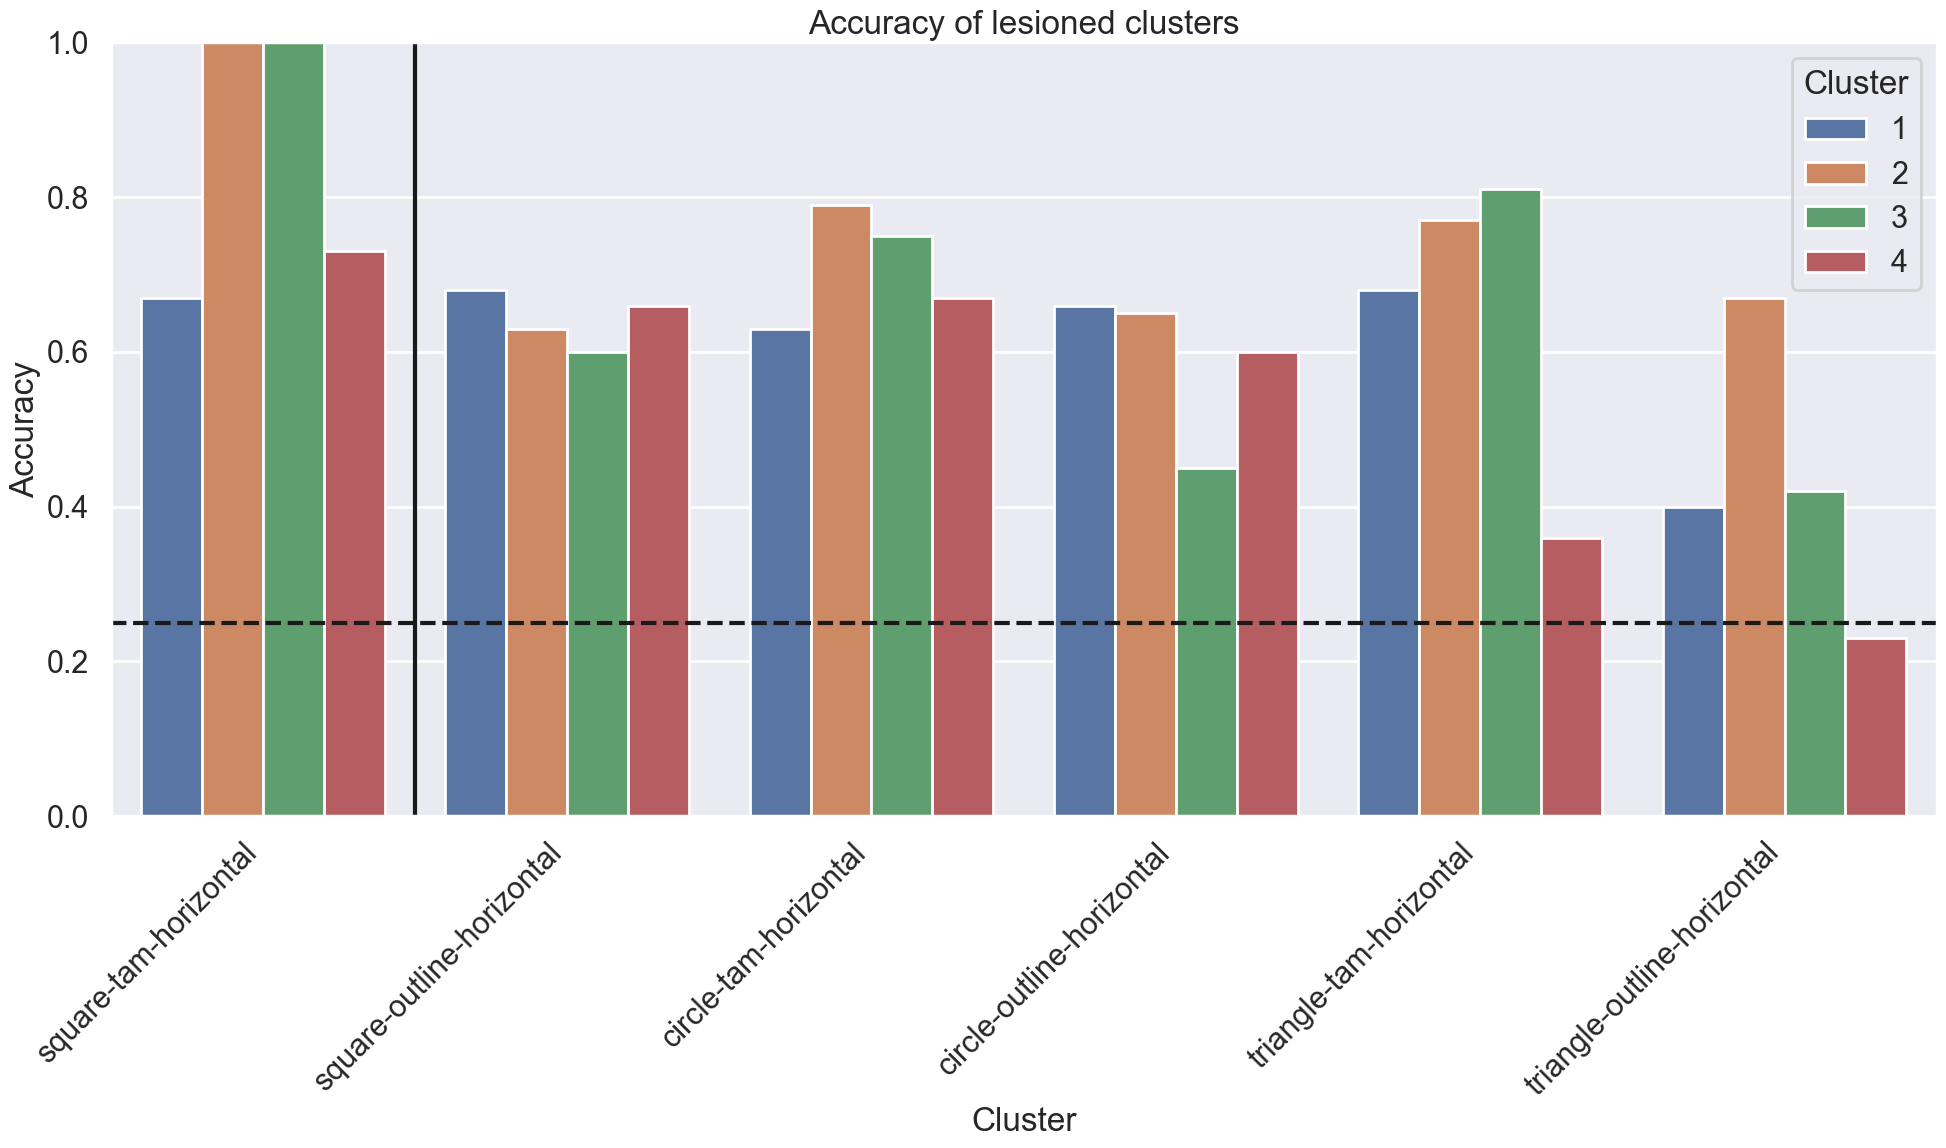

In [829]:
# plot the accuracy
fig, ax = plt.subplots(figsize=(20, 12))
sns.barplot(data=df, x="Dataset", y="Accuracy", hue="Cluster", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Cluster")
ax.set_title("Accuracy of lesioned clusters")
ax.axhline(y=0.25, color='k', ls='--')
# vertical line after first four bars
ax.axvline(x=0.5, color='k', ls='-')
# rotate xticks
plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()

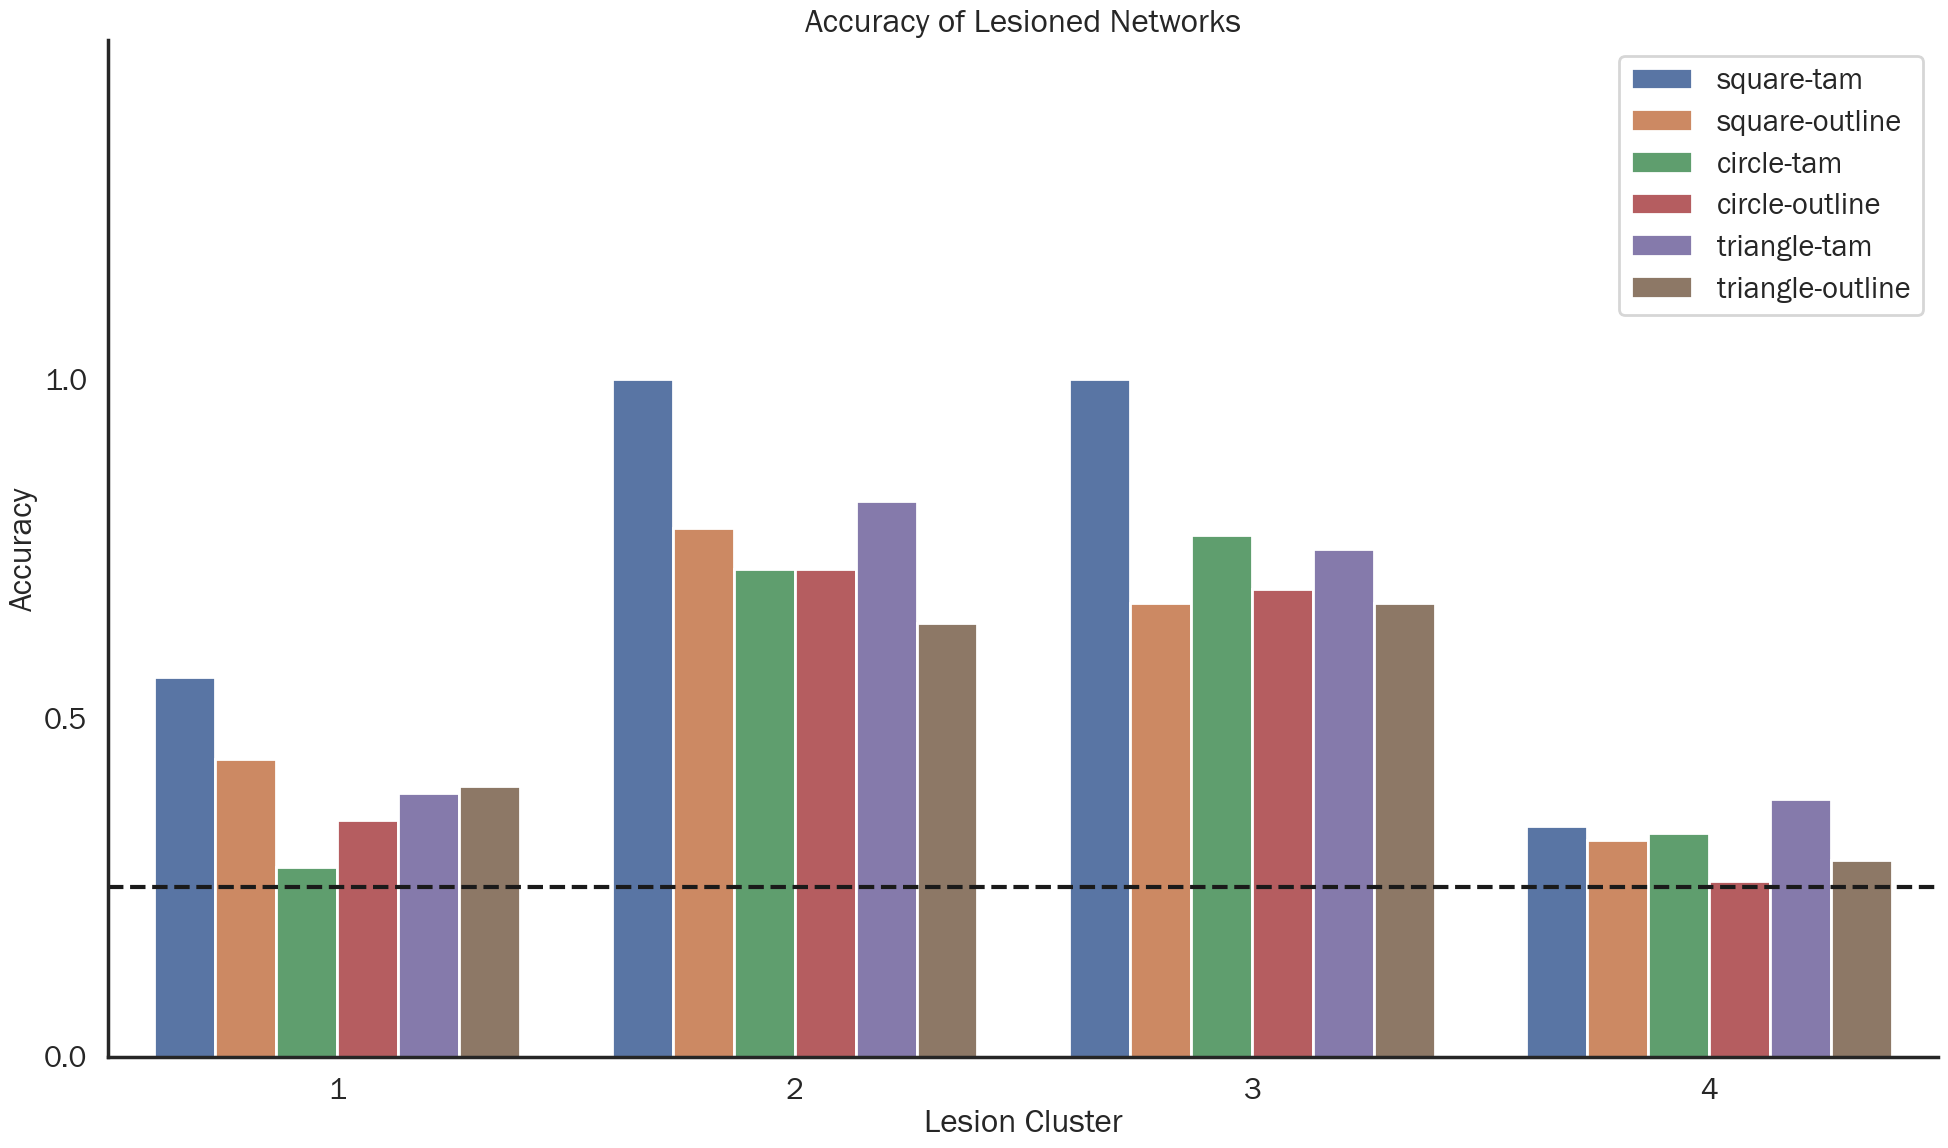

In [874]:
# plot the accuracy
fig, ax = plt.subplots(figsize=(20, 12))
sns.barplot(data=df, x="Cluster", y="Accuracy", hue="Dataset", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_xlabel("Lesion Cluster")
ax.set_title("Accuracy of Lesioned Networks")
ax.axhline(y=0.25, color='k', ls='--')
# vertical line after first four bars
# ax.axvline(x=0.5, color='k', ls='-')
# rotate xticks
# Change legend labels to be more descriptive
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=[label[:-11] for label in labels])

# plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.ylim(0, 1.5)
plt.yticks(np.arange(0, 1.5, 0.5))
plt.tight_layout()
plt.show()
# Save
fig.savefig(str(FIG_DIR / "lesion_analysis.png"))